In [1]:
# import the required packages

# to prevent UserWarning when using kmeans
import os
os.environ["OMP_NUM_THREADS"] = '1'

# importing the required libraries
import numpy as np
import pandas as pd
import random

import seaborn as sns

from matplotlib import pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.cluster import KMeans

import scipy.cluster.hierarchy as shc  

from sklearn.cluster import AgglomerativeClustering 
from sklearn.preprocessing import StandardScaler, normalize 
from sklearn.metrics import silhouette_score 
from scipy.spatial.distance import cdist

## Load Bank_Data 

In [2]:
bank_data = pd.read_csv("./data/Bank_data.csv")

In [3]:
# show the first 5 rows
bank_data.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Property,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,real estate,22,none,own,1,skilled employee / official,1,NaN,yes,2
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,real estate,49,none,own,1,unskilled - resident,2,NaN,yes,1
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,building society savings agreement/ life insur...,45,none,for free,1,skilled employee / official,2,NaN,yes,1
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,unknown / no property,53,none,for free,2,skilled employee / official,2,NaN,yes,2


In [4]:
# Check any null value
bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Account Status                                            1000 non-null   str  
 1   Duration in month                                         1000 non-null   int64
 2   Credit History                                            1000 non-null   str  
 3   Purpose                                                   1000 non-null   str  
 4   Credit amount                                             1000 non-null   int64
 5   Savings account or bonds                                  1000 non-null   str  
 6   Present employment since                                  1000 non-null   str  
 7   Instalment rate in percentage of disposable income        1000 non-null   int64
 8   Personal status and sex                           

In [5]:
# isnull
bank_data.isnull().sum()

Account Status                                                0
Duration in month                                             0
Credit History                                                0
Purpose                                                       0
Credit amount                                                 0
Savings account or bonds                                      0
Present employment since                                      0
Instalment rate in percentage of disposable income            0
Personal status and sex                                       0
Other debtors or guarantors                                   0
Present residence since                                       0
Property                                                      0
Age in years                                                  0
Other installment plans                                       0
Housing                                                       0
Number of existing credits at this bank 

# 1. Build Clustering Models using Numerical Data


### 1.1 Data exploration and manipulation

Categorical columns were excluded from the dataset because distance-based clustering models operate on numerical features and are not suitable for raw categorical data.

In [6]:
# removing those categorical data as it only uses numerical data
remove_features =  ['Account Status', 'Credit History', 'Purpose', 'Savings account or bonds', 'Present employment since', 
                    'Personal status and sex', 'Other debtors or guarantors', 'Property', 'Other installment plans', 'Housing',
                    'Job', 'Telephone', 'Foreign worker']

new_data = bank_data.drop(columns = remove_features)

In [7]:
new_data.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target
0,6,1169,4,4,67,2,1,1
1,48,5951,2,2,22,1,1,2
2,12,2096,2,3,49,1,2,1
3,42,7882,2,4,45,1,2,1
4,24,4870,3,4,53,2,2,2


In [8]:
new_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                                                    Non-Null Count  Dtype
---  ------                                                    --------------  -----
 0   Duration in month                                         1000 non-null   int64
 1   Credit amount                                             1000 non-null   int64
 2   Instalment rate in percentage of disposable income        1000 non-null   int64
 3   Present residence since                                   1000 non-null   int64
 4   Age in years                                              1000 non-null   int64
 5   Number of existing credits at this bank                   1000 non-null   int64
 6   Number of people being liable to provide maintenance for  1000 non-null   int64
 7   Target                                                    1000 non-null   int64
dtypes: int64(8)
memory usage: 62.6 KB


In [9]:
# check null value
new_data.isnull().mean() * 100

Duration in month                                           0.0
Credit amount                                               0.0
Instalment rate in percentage of disposable income          0.0
Present residence since                                     0.0
Age in years                                                0.0
Number of existing credits at this bank                     0.0
Number of people being liable to provide maintenance for    0.0
Target                                                      0.0
dtype: float64

In [10]:
new_data.describe()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


### 1.1 Visualsation of Numerical Data

In [11]:
new_data.head()

,Duration in month,Credit amount,Instalment rate in percentage of disposable income,Present residence since,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for,Target
0,6,1169,4,4,67,2,1,1
1,48,5951,2,2,22,1,1,2
2,12,2096,2,3,49,1,2,1
3,42,7882,2,4,45,1,2,1
4,24,4870,3,4,53,2,2,2


**KMean & Hierarchical**


| Model | Features   | Clusters value | Silhouette Score -> bar chart   |
|-------|------------|----------------|---------------------------------|

|Sample| KMean / Hierarchical | VarA, VarB                       |     Cluster    |          Silhouette Score       |Linkage|
|------|-------|----------------------------------|----------------|---------------------------------|-------|
|Sample| Kmean / Hierarchical | Duration in month, Credit amount |        1       |                0.9              | Nil / ward |

|Actual| KMean | VarA, VarB, VarC                 |
|------|-------|----------------------------------|
| 01   | Kmean | "Duration in month", "Credit amount" |
| 02   | Kmean | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |
| 03   | Kmean | "Duration in month", "Credit amount", "Age in years" |
| 04   | Kmean | "Age in years", "Number of existing credits at this bank" |

|Actual| Hierarchical | VarA, VarB, VarC                 |Linkage|
|------|--------------|----------------------------------|--------|
| 05   | Hierarchical | "Duration in month", "Credit amount" | Ward|
| 06   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" | Ward |
| 07   | Hierarchical | "Duration in month", "Credit amount", "Age in years" | Ward |
| 08   | Hierarchical | "Age in years", "Number of existing credits at this bank | Ward |

|Actual| Hierarchical | VarA, VarB, VarC                 |Linkage|
|------|--------------|----------------------------------|-------|
| 09   | Hierarchical | "Duration in month", "Credit amount"| Average |
| 10   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for"   | Average |
| 11   | Hierarchical | "Duration in month", "Credit amount", "Age in years" | Average |
| 12   | Hierarchical | "Age in years", "Number of existing credits at this bank" | Average |

|Actual| Hierarchical | VarA, VarB, VarC                 |Linkage|
|------|--------------|----------------------------------|-------|
| 13   | Hierarchical | "Duration in month", "Credit amount"|   Single |
| 14   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |    Single |
| 15   | Hierarchical | "Duration in month", "Credit amount", "Age in years" | Single |
| 16   | Hierarchical | "Age in years", "Number of existing credits at this bank" | Single|

|Actual| Hierarchical | VarA, VarB, VarC                 |Linkage|
|------|--------------|----------------------------------|-------|
| 17   | Hierarchical | "Duration in month", "Credit amount"| Complete |
| 18   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for"   | Complete |
| 19   | Hierarchical | "Duration in month", "Credit amount", "Age in years" | Complete|
| 20   | Hierarchical | "Age in years", "Number of existing credits at this bank" | Complete |

### 1.2 K-Means Clustering

**4 Model**

In [12]:
# new_data_01 = new_data.drop(columns = ['Duration in month', 
#                                        'Credit amount', 
#                                        'Instalment rate in percentage of disposable income', 
#                                        'Present residence since',
#                                        'Age in years', 
#                                        'Number of existing credits at this bank',
#                                        'Number of people being liable to provide maintenance for', 
#                                        'Target'])

**Model 01**

In [13]:
# original = new_data.drop(columns = ['Duration in month', 
#                                     'Credit amount', 
#                                     'Instalment rate in percentage of disposable income', 
#                                     'Present residence since',
#                                     'Age in years', 
#                                     'Number of existing credits at this bank',
#                                     'Number of people being liable to provide maintenance for', 
#                                     'Target'])

In [14]:
# Use "Duration in month", "Credit amount" for the Silhouette Score

# drop "Present residence since", "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for", "Target"
remove_features_01 = ["Instalment rate in percentage of disposable income", "Present residence since", "Age in years", "Number of existing credits at this bank",
                      "Number of people being liable to provide maintenance for", "Target"]

model_01 = new_data.drop(columns = remove_features_01)

In [15]:
X_01 = model_01.values

In [16]:
X_01

array([[   6, 1169],
       [  48, 5951],
       [  12, 2096],
       ...,
       [  12,  804],
       [  45, 1845],
       [  45, 4576]], shape=(1000, 2))

In [17]:
# Scaling the data so that all the features/attributes become comparable (z-score normalisation)
scaler = StandardScaler() 
X_scaled_01 = scaler.fit_transform(X_01) 

In [18]:
X_scaled_01

array([[-1.23647786, -0.74513141],
       [ 2.24819436,  0.94981679],
       [-0.73866754, -0.41656241],
       ...,
       [-0.73866754, -0.87450324],
       [ 1.9992892 , -0.50552769],
       [ 1.9992892 ,  0.46245715]], shape=(1000, 2))

In [19]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2,11)
silhouette_scores_01 = [ ]

for k in k_range:
    kmeans_01 = KMeans(n_clusters = k, max_iter = 55, random_state = 1000, algorithm = "elkan")
    
    labels_01 = kmeans_01.fit_predict(X_scaled_01)
    
    score_01 = silhouette_score(X_scaled_01, labels_01)
    
    silhouette_scores_01.append(score_01)

In [20]:
silhouette_scores_01

[0.5801912097451697,
 0.4455295010628648,
 0.4294842647939699,
 0.4362173366684051,
 0.43444988007612495,
 0.41730487562142626,
 0.371329882913228,
 0.37300253238488523,
 0.3776680376955235]

In [21]:
score_01

0.3776680376955235

In [22]:
best_k_01 = k_range[silhouette_scores_01.index(max(silhouette_scores_01))]
print("Best k:", best_k_01)


Best k: 2


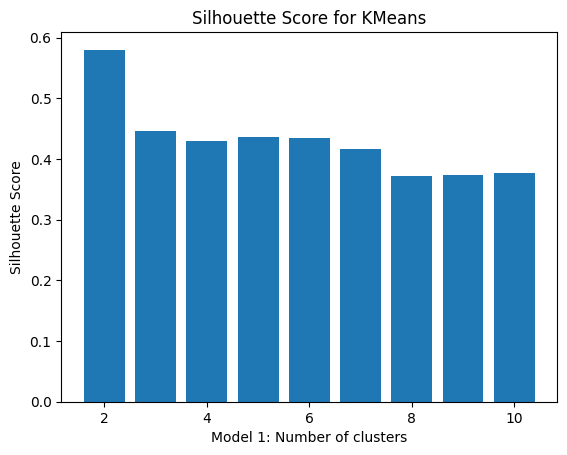

In [23]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_01)
plt.xlabel('Model 1: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans')
plt.show()

**Model 02**

In [24]:
# Use "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for"
# drop "Duration in month", "Credit amount", "Instalment rate in percentage of disposable income" for the Silhouette Score, "Present residence since", "Target"
remove_features_02 = ["Duration in month", "Credit amount", "Instalment rate in percentage of disposable income", 
                      "Present residence since", "Target"]

model_02 = new_data.drop(columns = remove_features_02)

In [25]:
model_02.head()

,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
0,67,2,1
1,22,1,1
2,49,1,2
3,45,1,2
4,53,2,2


In [26]:
X_02 = model_02.values

In [27]:
X_02

array([[67,  2,  1],
       [22,  1,  1],
       [49,  1,  2],
       ...,
       [38,  1,  1],
       [23,  1,  1],
       [27,  1,  1]], shape=(1000, 3))

In [28]:
# Scaling the data so that all the features/attributes become comparable (z-score normalisation)
scaler = StandardScaler() 
X_scaled_02 = scaler.fit_transform(X_02) 

In [29]:
X_scaled_02

array([[ 2.76645648,  1.02707891, -0.42828957],
       [-1.19140394, -0.704926  , -0.42828957],
       [ 1.18331231, -0.704926  ,  2.33486893],
       ...,
       [ 0.21583532, -0.704926  , -0.42828957],
       [-1.10345149, -0.704926  , -0.42828957],
       [-0.75164167, -0.704926  , -0.42828957]], shape=(1000, 3))

In [30]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2,11)
silhouette_scores_02 = [ ]

for k in k_range:
    kmeans_02 = KMeans(n_clusters = k, max_iter = 55, random_state = 1000, algorithm = "elkan")
    
    labels_02 = kmeans_02.fit_predict(X_scaled_02)
    
    score_02 = silhouette_score(X_scaled_02, labels_02)
    
    silhouette_scores_02.append(score_02)

In [31]:
silhouette_scores_02

[0.5097163323319218,
 0.38638411495533337,
 0.5704857964529526,
 0.5885648149092789,
 0.6002073234036293,
 0.5726120599691458,
 0.5903963336664081,
 0.5801633098232681,
 0.5736659514799032]

In [32]:
score_02

0.5736659514799032

In [33]:
best_k_02 = k_range[silhouette_scores_02.index(max(silhouette_scores_02))]
print("Best k:", best_k_02)

Best k: 6


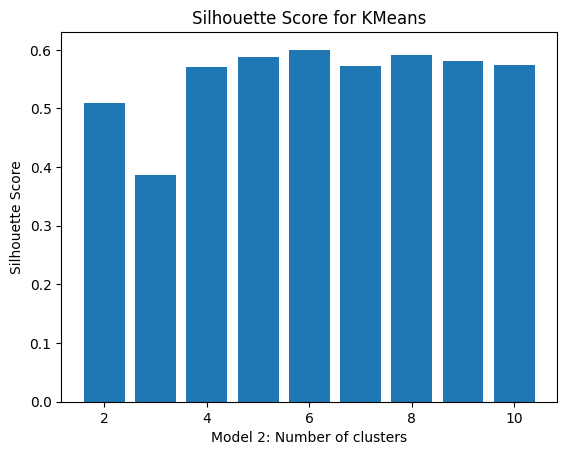

In [34]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_02)
plt.xlabel('Model 2: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans')
plt.show()

**Model 03**

In [35]:
# Use "Duration in month", "Credit amount", "Age in years"
# drop "Instalment rate in percentage of disposable income", "Present residence since", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for", "Target"
remove_features_03 = ["Instalment rate in percentage of disposable income", "Present residence since", 
                      "Number of existing credits at this bank", "Number of people being liable to provide maintenance for", "Target"]

model_03 = new_data.drop(columns = remove_features_03)

In [36]:
model_03.head()

,Duration in month,Credit amount,Age in years
0,6,1169,67
1,48,5951,22
2,12,2096,49
3,42,7882,45
4,24,4870,53


In [37]:
X_03 = model_03.values

In [38]:
X_03

array([[   6, 1169,   67],
       [  48, 5951,   22],
       [  12, 2096,   49],
       ...,
       [  12,  804,   38],
       [  45, 1845,   23],
       [  45, 4576,   27]], shape=(1000, 3))

In [39]:
# Scaling the data so that all the features/attributes become comparable (z-score normalisation)
scaler = StandardScaler() 
X_scaled_03 = scaler.fit_transform(X_03) 

In [40]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2,11)
silhouette_scores_03 = [ ]

for k in k_range:
    kmeans_03 = KMeans(n_clusters = k, max_iter = 55, random_state = 1000, algorithm = "elkan")
    
    labels_03 = kmeans_03.fit_predict(X_scaled_03)
    
    score_03 = silhouette_score(X_scaled_03, labels_03)
    
    silhouette_scores_03.append(score_03)

In [41]:
silhouette_scores_03

[0.4346161965920348,
 0.3894237180526776,
 0.31799306633484664,
 0.27405009889830256,
 0.28455764551094037,
 0.2995670833601712,
 0.29209794939047096,
 0.2909930340556831,
 0.27987608980281264]

In [42]:
score_03

0.27987608980281264

In [43]:
best_k_03 = k_range[silhouette_scores_03.index(max(silhouette_scores_03))]
print("Best k:", best_k_03)

Best k: 2


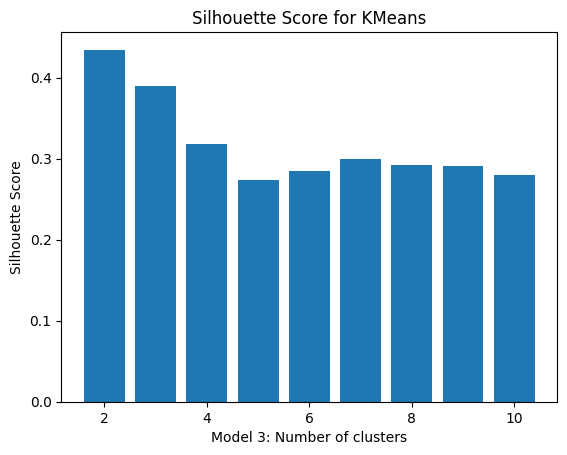

In [44]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_03)
plt.xlabel('Model 3: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans')
plt.show()

**Model 04**

In [45]:
# Use this for Model 4 -> "Age in years", "Number of existing credits at this bank"
# drop "Instalment rate in percentage of disposable income", "Present residence since", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for", "Target"
remove_features_04 = ['Duration in month', 
                     'Credit amount', 
                     'Instalment rate in percentage of disposable income', 
                     'Present residence since',
                     'Number of people being liable to provide maintenance for', 
                     'Target']

model_04 = new_data.drop(columns = remove_features_04)

In [46]:
model_04.head()

,Age in years,Number of existing credits at this bank
0,67,2
1,22,1
2,49,1
3,45,1
4,53,2


In [47]:
X_04 = model_04.values

In [48]:
X_04

array([[67,  2],
       [22,  1],
       [49,  1],
       ...,
       [38,  1],
       [23,  1],
       [27,  1]], shape=(1000, 2))

In [49]:
# Scaling the data so that all the features/attributes become comparable (z-score normalisation)
scaler = StandardScaler() 
X_scaled_04 = scaler.fit_transform(X_04) 

In [50]:
X_scaled_04

array([[ 2.76645648,  1.02707891],
       [-1.19140394, -0.704926  ],
       [ 1.18331231, -0.704926  ],
       ...,
       [ 0.21583532, -0.704926  ],
       [-1.10345149, -0.704926  ],
       [-0.75164167, -0.704926  ]], shape=(1000, 2))

In [51]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2,11)
silhouette_scores_04 = [ ]

for k in k_range:
    kmeans_04 = KMeans(n_clusters = k, max_iter = 55, random_state = 1000, algorithm = "elkan")
    
    labels_04 = kmeans_04.fit_predict(X_scaled_04)
    
    score_04 = silhouette_score(X_scaled_04, labels_04)

    silhouette_scores_04.append(score_04)

In [52]:
score_04

0.5691458269111519

In [53]:
silhouette_scores_04

[0.4258882470159848,
 0.5652391888595084,
 0.5839675893680654,
 0.5649060102982226,
 0.5813139171128425,
 0.5831059806674671,
 0.5862412201715027,
 0.5754091581982059,
 0.5691458269111519]

In [54]:
best_k_04 = k_range[silhouette_scores_04.index(max(silhouette_scores_04))]
print("Best k:", best_k_04)

Best k: 8


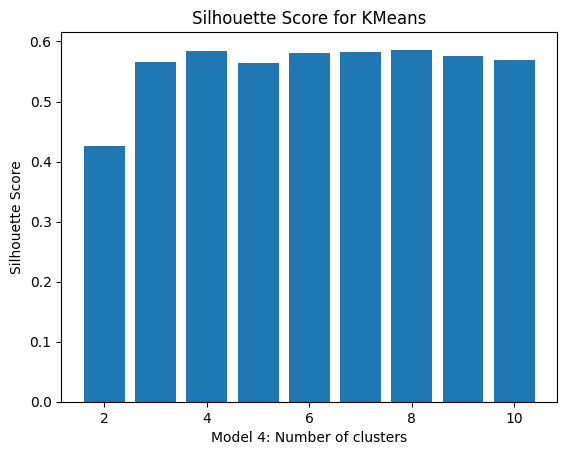

In [55]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_04)
plt.xlabel('Model 4: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for KMeans')
plt.show()

### 1.3 Hierarchical Clustering

**4 Model**

**Model 01**

In [56]:
remove_features_05 = remove_features_01.copy()

In [57]:
remove_features_05

['Instalment rate in percentage of disposable income',
 'Present residence since',
 'Age in years',
 'Number of existing credits at this bank',
 'Number of people being liable to provide maintenance for',
 'Target']

In [58]:
model_05 = new_data.drop(columns = remove_features_05)

In [59]:
model_05.head()

,Duration in month,Credit amount
0,6,1169
1,48,5951
2,12,2096
3,42,7882
4,24,4870


In [60]:
X_05 = model_05.values

In [61]:
X_05

array([[   6, 1169],
       [  48, 5951],
       [  12, 2096],
       ...,
       [  12,  804],
       [  45, 1845],
       [  45, 4576]], shape=(1000, 2))

In [62]:
# Scaling the data so that all the features/attributes become comparable 
scaler = StandardScaler() 
X_scaled_05 = scaler.fit_transform(X_05) 

In [63]:
# Perform hierarchical/agglomerative clustering
Z_05 = shc.linkage(X_scaled_05, 
                   method = 'ward')  # default 
Z_05 # A condensed distance matrix

array([[  25.        ,  536.        ,    0.        ,    2.        ],
       [  52.        ,  277.        ,    0.        ,    2.        ],
       [  66.        ,  892.        ,    0.        ,    2.        ],
       ...,
       [1989.        , 1993.        ,   17.56517284,  232.        ],
       [1994.        , 1996.        ,   21.32691556,  298.        ],
       [1995.        , 1997.        ,   46.387468  , 1000.        ]],
      shape=(999, 4))

In [64]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_05 = []

for i in k_range:
    ac_i_05 = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
    silhouette_scores_05.append(silhouette_score(X_scaled_05, ac_i_05.fit_predict(X_scaled_05)))

In [65]:
silhouette_scores_05

[0.5389876442823875,
 0.4912104546195229,
 0.4892715755365957,
 0.3852773574940233,
 0.38641242021250466,
 0.3914153104010086,
 0.3587991424031615,
 0.3343649056653329,
 0.33757233735332576]

In [66]:
best_k_05 = k_range[silhouette_scores_05.index(max(silhouette_scores_05))]
print("Best k:", best_k_05)

Best k: 2


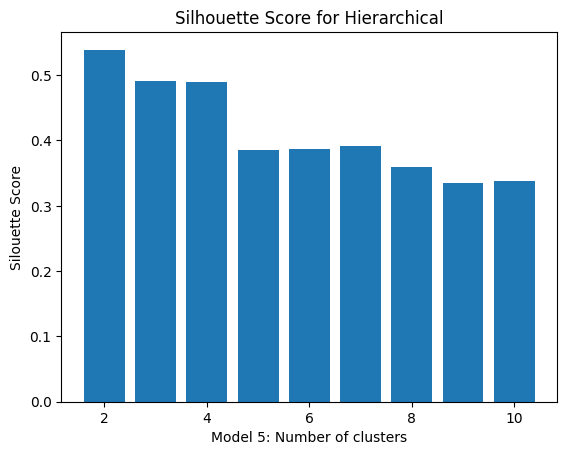

In [67]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_05) 
plt.xlabel('Model 5: Number of clusters') 
plt.ylabel('Silouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

In [68]:
ac__i_05_final = AgglomerativeClustering(n_clusters = 2, linkage = 'ward')

y_pred_05 = ac__i_05_final.fit_predict(X_scaled_05)

In [69]:
y_pred_05

array([1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,

**Model 06**

In [70]:
remove_features_06 = remove_features_02.copy()

In [71]:
model_06 = new_data.drop(columns = remove_features_06)

In [72]:
model_06.head()

,Age in years,Number of existing credits at this bank,Number of people being liable to provide maintenance for
0,67,2,1
1,22,1,1
2,49,1,2
3,45,1,2
4,53,2,2


In [73]:
X_06 = model_06.values

In [74]:
X_06

array([[67,  2,  1],
       [22,  1,  1],
       [49,  1,  2],
       ...,
       [38,  1,  1],
       [23,  1,  1],
       [27,  1,  1]], shape=(1000, 3))

In [75]:
# Scaling the data so that all the features/attributes become comparable 
scaler = StandardScaler() 
X_scaled_06 = scaler.fit_transform(X_06) 

In [76]:
X_scaled_06

array([[ 2.76645648,  1.02707891, -0.42828957],
       [-1.19140394, -0.704926  , -0.42828957],
       [ 1.18331231, -0.704926  ,  2.33486893],
       ...,
       [ 0.21583532, -0.704926  , -0.42828957],
       [-1.10345149, -0.704926  , -0.42828957],
       [-0.75164167, -0.704926  , -0.42828957]], shape=(1000, 3))

In [77]:
# Perform hierarchical/agglomerative clustering
Z_06 = shc.linkage(X_scaled_06, 
                   method = 'ward')  # default 
Z_06 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 5.60000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.98900000e+03, 1.99300000e+03, 2.84601067e+01, 5.50000000e+02],
       [1.99500000e+03, 1.99600000e+03, 3.71127207e+01, 8.45000000e+02],
       [1.99400000e+03, 1.99700000e+03, 4.52989674e+01, 1.00000000e+03]],
      shape=(999, 4))

In [78]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_06 = []

for i in k_range:
    ac_i_06 = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
    silhouette_scores_06.append(silhouette_score(X_scaled_06, ac_i_06.fit_predict(X_scaled_06)))

In [79]:
silhouette_scores_06

[0.5097163323319218,
 0.5060896933171785,
 0.5464139302552314,
 0.5819265661068383,
 0.600908986378681,
 0.5693335404513552,
 0.580029089031866,
 0.5850236684510601,
 0.5759244029054813]

In [80]:
best_k_06 = k_range[silhouette_scores_06.index(max(silhouette_scores_06))]
print("Best k:", best_k_06)

Best k: 6


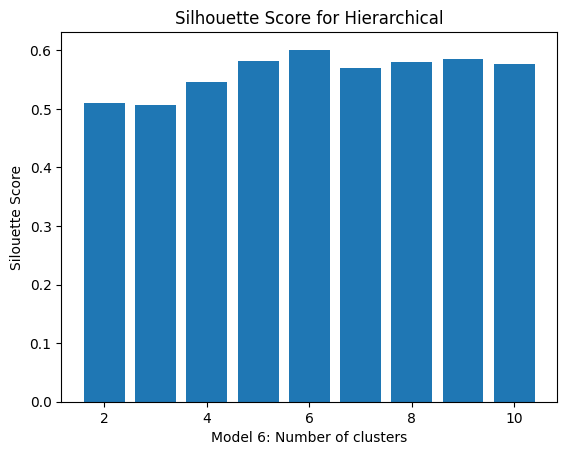

In [81]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_06) 
plt.xlabel('Model 6: Number of clusters') 
plt.ylabel('Silouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

**Model 07**

In [82]:
remove_features_07 = remove_features_03.copy()

In [83]:
model_07 = new_data.drop(columns = remove_features_07)

In [84]:
X_07 = model_07.values

In [85]:
X_07

array([[   6, 1169,   67],
       [  48, 5951,   22],
       [  12, 2096,   49],
       ...,
       [  12,  804,   38],
       [  45, 1845,   23],
       [  45, 4576,   27]], shape=(1000, 3))

In [86]:
# Scaling the data so that all the features/attributes become comparable 
scaler = StandardScaler() 
X_scaled_07 = scaler.fit_transform(X_07) 

In [87]:
# Perform hierarchical/agglomerative clustering
Z_07 = shc.linkage(X_scaled_07, 
                   method = 'ward')  # default 
Z_07 # A condensed distance matrix

array([[1.61000000e+02, 5.80000000e+02, 3.54443372e-04, 2.00000000e+00],
       [1.50000000e+01, 7.55000000e+02, 1.06333011e-03, 2.00000000e+00],
       [7.29000000e+02, 9.04000000e+02, 1.06333011e-03, 2.00000000e+00],
       ...,
       [1.98900000e+03, 1.99400000e+03, 2.25077368e+01, 3.85000000e+02],
       [1.99500000e+03, 1.99600000e+03, 3.43787559e+01, 9.06000000e+02],
       [1.99100000e+03, 1.99700000e+03, 4.08036335e+01, 1.00000000e+03]],
      shape=(999, 4))

In [88]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_07 = []

for i in k_range:
    ac_i_07 = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
    silhouette_scores_07.append(silhouette_score(X_scaled_07, ac_i_07.fit_predict(X_scaled_07)))

In [89]:
silhouette_scores_07

[0.4606601589330235,
 0.2908208745924065,
 0.24356403245389643,
 0.2403335756584133,
 0.2518491200823742,
 0.245851711928111,
 0.2522869088313338,
 0.25446852482704957,
 0.2626773127050419]

In [90]:
best_k_07 = k_range[silhouette_scores_07.index(max(silhouette_scores_07))]
print("Best k:", best_k_07)

Best k: 2


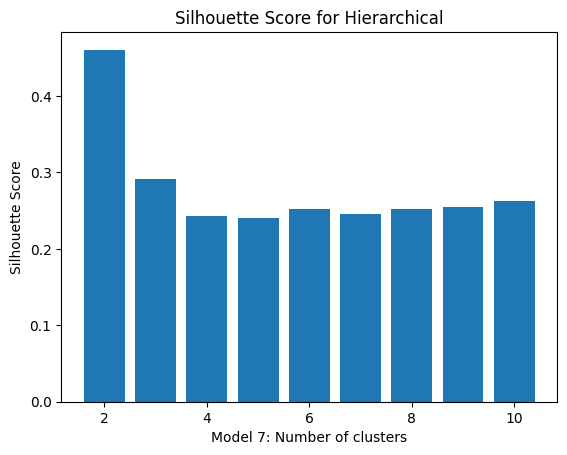

In [91]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_07)
plt.xlabel('Model 7: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

**Model 08**

In [92]:
remove_features_08 = remove_features_04.copy()

In [93]:
model_08 = new_data.drop(columns = remove_features_08)

In [94]:
model_08.head()

,Age in years,Number of existing credits at this bank
0,67,2
1,22,1
2,49,1
3,45,1
4,53,2


In [95]:
X_08 = model_08.values

In [96]:
X_08

array([[67,  2],
       [22,  1],
       [49,  1],
       ...,
       [38,  1],
       [23,  1],
       [27,  1]], shape=(1000, 2))

In [97]:
# Scaling the data so that all the features/attributes become comparable 
scaler = StandardScaler() 
X_scaled_08 = scaler.fit_transform(X_08) 

In [98]:
# Perform hierarchical/agglomerative clustering
Z_08 = shc.linkage(X_scaled_08, 
                   method = 'ward')  # default 
Z_08 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 2.77000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99300000e+03, 1.99500000e+03, 2.20185663e+01, 3.67000000e+02],
       [1.99200000e+03, 1.99400000e+03, 2.90004900e+01, 6.33000000e+02],
       [1.99600000e+03, 1.99700000e+03, 4.16802976e+01, 1.00000000e+03]],
      shape=(999, 4))

In [99]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_08 = []

for i in k_range:
    ac_i_08 = AgglomerativeClustering(n_clusters = i, linkage = 'ward')
    silhouette_scores_08.append(silhouette_score(X_scaled_08, ac_i_08.fit_predict(X_scaled_08)))

In [100]:
silhouette_scores_08

[0.5146919160784551,
 0.5416909635540793,
 0.5767530096975692,
 0.5881274127749511,
 0.5525348160693666,
 0.532018976874751,
 0.5202957350086699,
 0.524240115998554,
 0.5233733893962309]

In [101]:
best_k_08 = k_range[silhouette_scores_08.index(max(silhouette_scores_08))]
print("Best k:", best_k_08)

Best k: 5


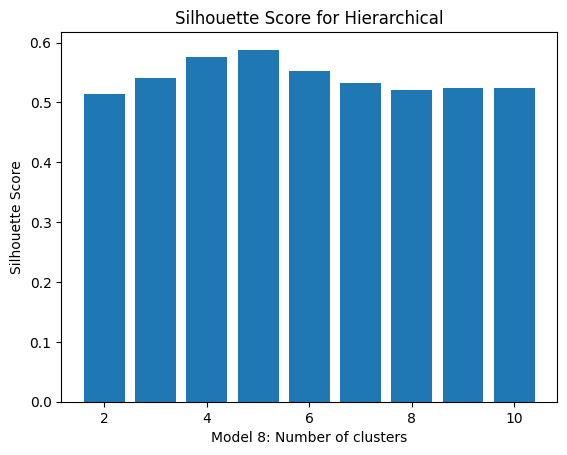

In [102]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_08)
plt.xlabel('Model 8: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

**Model 09**

In [103]:
X_09 = X_05.copy()

In [104]:
X_09

array([[   6, 1169],
       [  48, 5951],
       [  12, 2096],
       ...,
       [  12,  804],
       [  45, 1845],
       [  45, 4576]], shape=(1000, 2))

In [105]:
# Scaling the data so that all the features/attributes become comparable 
scaler = StandardScaler() 
X_scaled_09 = scaler.fit_transform(X_09) 

In [106]:
# Perform hierarchical/agglomerative clustering
Z_09 = shc.linkage(X_scaled_09, 
                   method = 'average')  # default 
Z_09 # A condensed distance matrix

array([[  25.        ,  536.        ,    0.        ,    2.        ],
       [  52.        ,  277.        ,    0.        ,    2.        ],
       [  66.        ,  892.        ,    0.        ,    2.        ],
       ...,
       [1989.        , 1994.        ,    2.52445991,   48.        ],
       [1797.        , 1996.        ,    3.58017954,   50.        ],
       [1995.        , 1997.        ,    4.03950925, 1000.        ]],
      shape=(999, 4))

In [107]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_09 = []

for i in k_range:
    ac_i_09 = AgglomerativeClustering(n_clusters = i, linkage = 'average')
    silhouette_scores_09.append(silhouette_score(X_scaled_09, ac_i_09.fit_predict(X_scaled_09)))

In [108]:
silhouette_scores_09

[0.6217746575789506,
 0.6092336477824133,
 0.5774829774464195,
 0.5033412569260604,
 0.5006857437038212,
 0.47088438598848,
 0.4712532130301486,
 0.46406777344089273,
 0.4629981074005866]

In [109]:
best_k_09 = k_range[silhouette_scores_09.index(max(silhouette_scores_09))]
print("Best k:", best_k_09)

Best k: 2


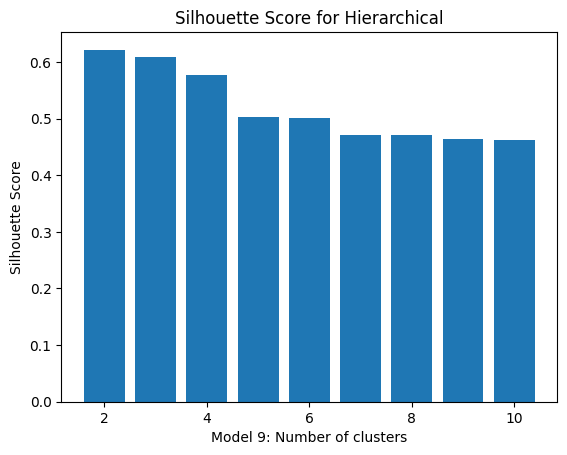

In [110]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_09)
plt.xlabel('Model 9: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

**Model 10**

In [111]:
X_scaled_10 = X_06.copy()

In [112]:
X_scaled_10

array([[67,  2,  1],
       [22,  1,  1],
       [49,  1,  2],
       ...,
       [38,  1,  1],
       [23,  1,  1],
       [27,  1,  1]], shape=(1000, 3))

In [113]:
# Perform hierarchical/agglomerative clustering
Z_10 = shc.linkage(X_scaled_10, 
                   method = 'average')  # default 
Z_10 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 5.60000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.97300000e+03, 1.99200000e+03, 1.10291482e+01, 5.40000000e+01],
       [1.99400000e+03, 1.99600000e+03, 1.57266973e+01, 2.33000000e+02],
       [1.99500000e+03, 1.99700000e+03, 2.21966189e+01, 1.00000000e+03]],
      shape=(999, 4))

In [114]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_10 = []

for i in k_range:
    ac_i_10 = AgglomerativeClustering(n_clusters = i, linkage = 'average')
    silhouette_scores_10.append(silhouette_score(X_scaled_10, ac_i_10.fit_predict(X_scaled_10)))

In [115]:
silhouette_scores_10

[0.628619413638489,
 0.567335355058547,
 0.5602689388547217,
 0.5313285662272206,
 0.532914994939467,
 0.5054636549145742,
 0.502273413905556,
 0.4920563642000807,
 0.4935818485784092]

In [116]:
best_k_10 = k_range[silhouette_scores_10.index(max(silhouette_scores_10))]
print("Best k:", best_k_10)

Best k: 2


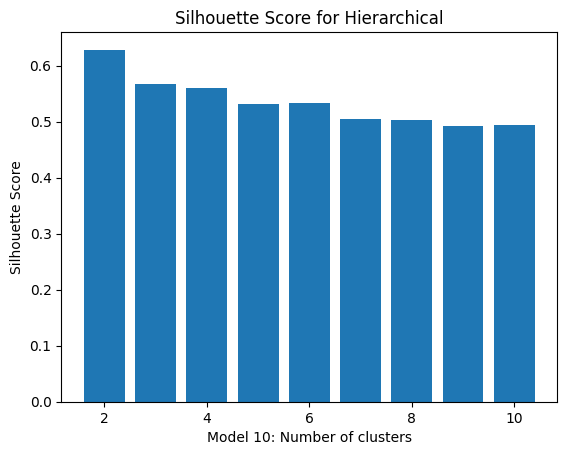

In [117]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_10)
plt.xlabel('Model 10: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

In [118]:
ac__i_10_final = AgglomerativeClustering(n_clusters = 2, linkage = 'average')

y_pred_10 = ac__i_10_final.fit_predict(X_scaled_10)

In [119]:
y_pred_10

array([0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,

**Model 11**

In [120]:
X_scaled_11 = X_07.copy()

In [121]:
X_scaled_11

array([[   6, 1169,   67],
       [  48, 5951,   22],
       [  12, 2096,   49],
       ...,
       [  12,  804,   38],
       [  45, 1845,   23],
       [  45, 4576,   27]], shape=(1000, 3))

In [122]:
# Perform hierarchical/agglomerative clustering
Z_11 = shc.linkage(X_scaled_11, 
                   method = 'average')  # default 
Z_11 # A condensed distance matrix

array([[1.61000000e+02, 5.80000000e+02, 1.00000000e+00, 2.00000000e+00],
       [7.85000000e+02, 8.76000000e+02, 1.41421356e+00, 2.00000000e+00],
       [7.10000000e+01, 8.23000000e+02, 1.73205081e+00, 2.00000000e+00],
       ...,
       [9.15000000e+02, 1.99100000e+03, 3.58569205e+03, 1.30000000e+01],
       [1.99300000e+03, 1.99500000e+03, 5.78406329e+03, 9.87000000e+02],
       [1.99600000e+03, 1.99700000e+03, 1.19990216e+04, 1.00000000e+03]],
      shape=(999, 4))

In [123]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_11 = []

for i in k_range:
    ac_i_11 = AgglomerativeClustering(n_clusters = i, linkage = 'average')
    silhouette_scores_11.append(silhouette_score(X_scaled_11, ac_i_11.fit_predict(X_scaled_11)))

In [124]:
silhouette_scores_11

[0.7466770895205375,
 0.6996897138546515,
 0.6959814174618475,
 0.6375296472161396,
 0.6388331376750932,
 0.5865974387744968,
 0.5817506373801855,
 0.5826340723301614,
 0.5812873889230131]

In [125]:
best_k_11 = k_range[silhouette_scores_11.index(max(silhouette_scores_11))]
print("Best k:", best_k_11)

Best k: 2


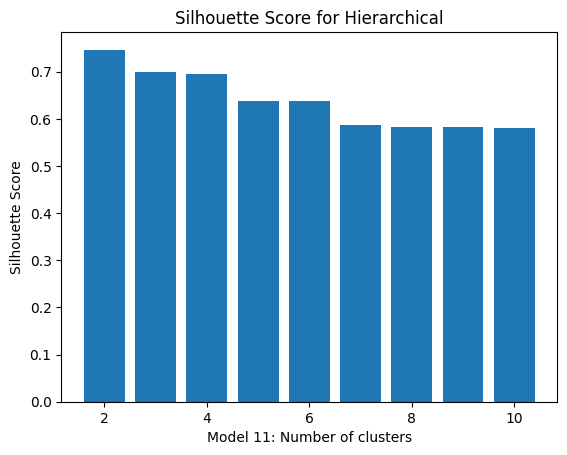

In [126]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_11)
plt.xlabel('Model 11: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

In [127]:
ac__i_11_final = AgglomerativeClustering(n_clusters = 2, linkage = 'average')

y_pred_11 = ac__i_11_final.fit_predict(X_scaled_11)

In [128]:
y_pred_11

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 12**

In [129]:
X_scaled_12 = X_08.copy()

In [130]:
X_scaled_12

array([[67,  2],
       [22,  1],
       [49,  1],
       ...,
       [38,  1],
       [23,  1],
       [27,  1]], shape=(1000, 2))

In [131]:
# Perform hierarchical/agglomerative clustering
Z_12 = shc.linkage(X_scaled_12, 
                   method = 'average')  # default 
Z_12 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 2.77000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99300000e+03, 1.99500000e+03, 1.41791399e+01, 3.02000000e+02],
       [1.99400000e+03, 1.99600000e+03, 1.99592819e+01, 9.94000000e+02],
       [1.96900000e+03, 1.99700000e+03, 3.90359868e+01, 1.00000000e+03]],
      shape=(999, 4))

In [132]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_12 = []

for i in k_range:
    ac_i_12 = AgglomerativeClustering(n_clusters = i, linkage = 'average')
    silhouette_scores_12.append(silhouette_score(X_scaled_12, ac_i_12.fit_predict(X_scaled_12)))

In [133]:
silhouette_scores_12

[0.6233747709090849,
 0.5798309812592052,
 0.5345182072090101,
 0.5331699870998885,
 0.5344909379428325,
 0.5110897132617008,
 0.5068150191136895,
 0.5008458326953921,
 0.5028574919541514]

In [134]:
best_k_12 = k_range[silhouette_scores_12.index(max(silhouette_scores_12))]
print("Best k:", best_k_12)

Best k: 2


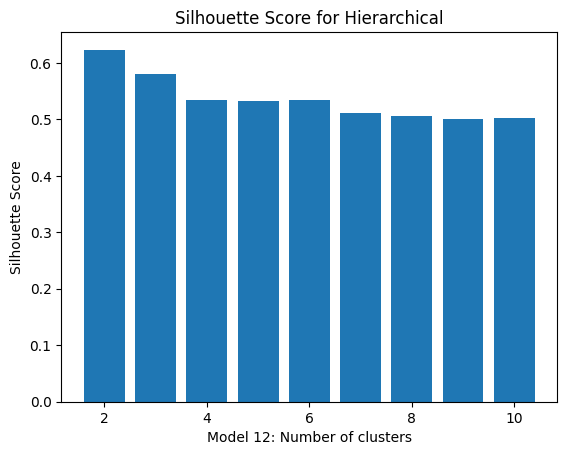

In [135]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_12)
plt.xlabel('Model 12: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical')
plt.show()

In [136]:
ac__i_12_final = AgglomerativeClustering(n_clusters = 2, linkage = 'average')

y_pred_12 = ac__i_12_final.fit_predict(X_scaled_12)

In [137]:
y_pred_12

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 13**

In [138]:
X_scaled_13 = X_09.copy()

In [139]:
X_scaled_13

array([[   6, 1169],
       [  48, 5951],
       [  12, 2096],
       ...,
       [  12,  804],
       [  45, 1845],
       [  45, 4576]], shape=(1000, 2))

In [140]:
# Perform hierarchical/agglomerative clustering
Z_13 = shc.linkage(X_scaled_13, 
                   method = 'single')  # default 
Z_13 # A condensed distance matrix

array([[2.45000000e+02, 9.75000000e+02, 0.00000000e+00, 2.00000000e+00],
       [5.20000000e+01, 2.77000000e+02, 0.00000000e+00, 2.00000000e+00],
       [2.50000000e+01, 5.36000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.98700000e+03, 1.99400000e+03, 7.58923580e+02, 1.20000000e+01],
       [1.99500000e+03, 1.99600000e+03, 7.81129951e+02, 9.99000000e+02],
       [9.15000000e+02, 1.99700000e+03, 2.47900726e+03, 1.00000000e+03]],
      shape=(999, 4))

In [141]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_13 = []

for i in k_range:
    ac_i_13 = AgglomerativeClustering(n_clusters = i, linkage = 'single')
    silhouette_scores_13.append(silhouette_score(X_scaled_13, ac_i_13.fit_predict(X_scaled_13)))

In [142]:
silhouette_scores_13

[0.782247185921756,
 0.7371099088892399,
 0.7247340183912512,
 0.6872444984492952,
 0.6824347734150549,
 0.6826896734542365,
 0.6426218407652833,
 0.6390979408512453,
 0.6252657741364399]

In [143]:
best_k_13 = k_range[silhouette_scores_13.index(max(silhouette_scores_13))]
print("Best k:", best_k_13)

Best k: 2


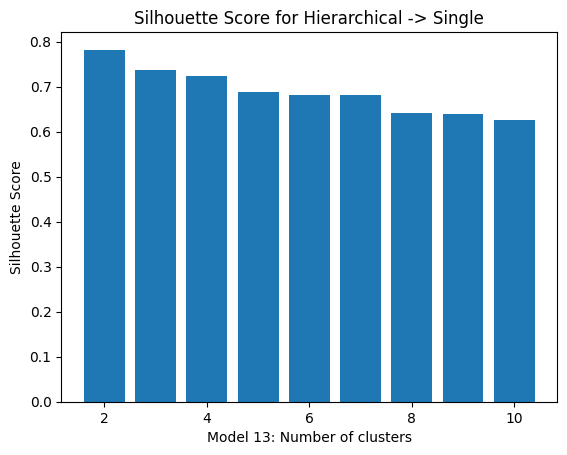

In [144]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_13)
plt.xlabel('Model 13: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> Single')
plt.show()

In [145]:
ac__i_13_final = AgglomerativeClustering(n_clusters = 2, linkage = 'single')

y_pred_13 = ac__i_13_final.fit_predict(X_scaled_13)

In [146]:
y_pred_13

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 14**

In [147]:
X_scaled_14 = X_scaled_10.copy()

In [148]:
X_scaled_14

array([[67,  2,  1],
       [22,  1,  1],
       [49,  1,  2],
       ...,
       [38,  1,  1],
       [23,  1,  1],
       [27,  1,  1]], shape=(1000, 3))

In [149]:
# Perform hierarchical/agglomerative clustering
Z_14 = shc.linkage(X_scaled_14, 
                   method = 'single')  # default 
Z_14 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.37000000e+02, 2.13000000e+02, 0.00000000e+00, 2.00000000e+00],
       [7.23000000e+02, 1.00100000e+03, 0.00000000e+00, 3.00000000e+00],
       ...,
       [7.56000000e+02, 1.98800000e+03, 1.73205081e+00, 6.00000000e+00],
       [1.63000000e+02, 1.99500000e+03, 2.00000000e+00, 9.94000000e+02],
       [1.99600000e+03, 1.99700000e+03, 4.00000000e+00, 1.00000000e+03]],
      shape=(999, 4))

In [150]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_14 = []

for i in k_range:
    ac_i_14 = AgglomerativeClustering(n_clusters = i, linkage = 'single')
    silhouette_scores_14.append(silhouette_score(X_scaled_14, ac_i_14.fit_predict(X_scaled_14)))

In [151]:
silhouette_scores_14

[0.6227829518889962,
 0.5715044754293508,
 0.5697818634764269,
 -0.04365096501360091,
 -0.05112009611829718,
 -0.09615792117211977,
 -0.10911412612897028,
 -0.5708125417611704,
 -0.5841120528853221]

In [152]:
best_k_14 = k_range[silhouette_scores_14.index(max(silhouette_scores_14))]
print("Best k:", best_k_14)

Best k: 2


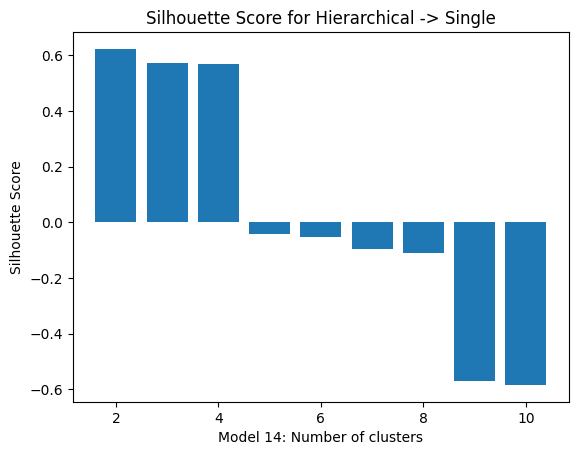

In [153]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_14)
plt.xlabel('Model 14: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> Single')
plt.show()

**Model 15**

In [154]:
X_scaled_15 = X_scaled_11.copy()

In [155]:
X_scaled_15

array([[   6, 1169,   67],
       [  48, 5951,   22],
       [  12, 2096,   49],
       ...,
       [  12,  804,   38],
       [  45, 1845,   23],
       [  45, 4576,   27]], shape=(1000, 3))

In [156]:
# Perform hierarchical/agglomerative clustering
Z_15 = shc.linkage(X_scaled_15, 
                   method = 'single')  # default 
Z_15 # A condensed distance matrix

array([[1.61000000e+02, 5.80000000e+02, 1.00000000e+00, 2.00000000e+00],
       [7.85000000e+02, 8.76000000e+02, 1.41421356e+00, 2.00000000e+00],
       [3.08000000e+02, 3.50000000e+02, 1.73205081e+00, 2.00000000e+00],
       ...,
       [1.98700000e+03, 1.99400000e+03, 7.60377538e+02, 1.20000000e+01],
       [1.99500000e+03, 1.99600000e+03, 7.81529910e+02, 9.99000000e+02],
       [9.15000000e+02, 1.99700000e+03, 2.47914360e+03, 1.00000000e+03]],
      shape=(999, 4))

In [157]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_15 = []

for i in k_range:
    ac_i_15 = AgglomerativeClustering(n_clusters = i, linkage = 'single')
    silhouette_scores_15.append(silhouette_score(X_scaled_15, ac_i_15.fit_predict(X_scaled_15)))

In [158]:
silhouette_scores_15

[0.7822310431543447,
 0.7370872040706646,
 0.7247037158889932,
 0.6872076294490812,
 0.6824014166460054,
 0.6826653841803239,
 0.6425945665237531,
 0.6390694647364777,
 0.6252307095464072]

In [159]:
best_k_15 = k_range[silhouette_scores_15.index(max(silhouette_scores_15))]
print("Best k:", best_k_15)

Best k: 2


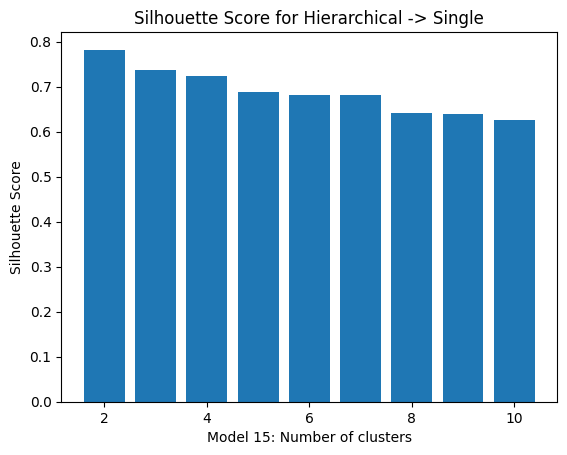

In [160]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_15)
plt.xlabel('Model 15: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> Single')
plt.show()

In [161]:
ac__i_15_final = AgglomerativeClustering(n_clusters = 2, linkage = 'single')

y_pred_15 = ac__i_15_final.fit_predict(X_scaled_15)

In [162]:
y_pred_15

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 16**

In [163]:
X_scaled_16 = X_04.copy()

In [164]:
X_scaled_16

array([[67,  2],
       [22,  1],
       [49,  1],
       ...,
       [38,  1],
       [23,  1],
       [27,  1]], shape=(1000, 2))

In [165]:
# Perform hierarchical/agglomerative clustering
Z_16 = shc.linkage(X_scaled_16, 
                   method = 'single')
Z_16 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.37000000e+02, 2.13000000e+02, 0.00000000e+00, 2.00000000e+00],
       [7.23000000e+02, 1.00100000e+03, 0.00000000e+00, 3.00000000e+00],
       ...,
       [7.56000000e+02, 1.99100000e+03, 1.41421356e+00, 6.00000000e+00],
       [1.63000000e+02, 1.99500000e+03, 2.00000000e+00, 9.94000000e+02],
       [1.99600000e+03, 1.99700000e+03, 4.00000000e+00, 1.00000000e+03]],
      shape=(999, 4))

In [166]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_16 = []

for i in k_range:
    ac_i_16 = AgglomerativeClustering(n_clusters = i, linkage = 'single')
    silhouette_scores_16.append(silhouette_score(X_scaled_16, ac_i_16.fit_predict(X_scaled_16)))

In [167]:
silhouette_scores_16

[0.6233747709090849,
 0.572515653522788,
 0.5708405849155783,
 0.5041335704380777,
 0.37861381793316146,
 -0.3776935803620046,
 -0.34230843522539456,
 -0.34273622162989453,
 -0.342029114848708]

In [168]:
best_k_16 = k_range[silhouette_scores_16.index(max(silhouette_scores_16))]
print("Best k:", best_k_16)

Best k: 2


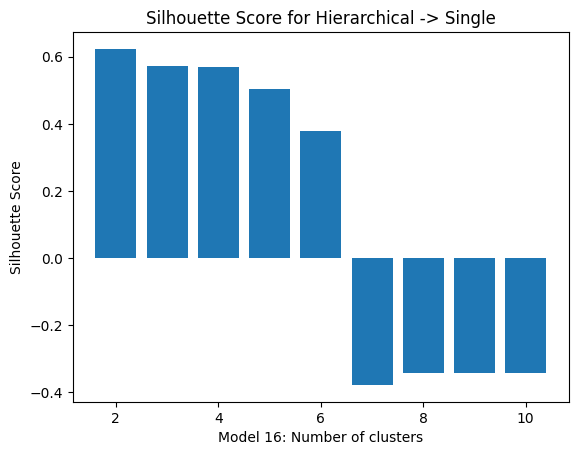

In [169]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_16)
plt.xlabel('Model 16: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> Single')
plt.show()

In [170]:
ac__i_16_final = AgglomerativeClustering(n_clusters = 2, linkage = 'single')

y_pred_16 = ac__i_16_final.fit_predict(X_scaled_16)

In [171]:
y_pred_16

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 17**

In [172]:
X_scaled_17 = X_01.copy()

In [173]:
X_scaled_17

array([[   6, 1169],
       [  48, 5951],
       [  12, 2096],
       ...,
       [  12,  804],
       [  45, 1845],
       [  45, 4576]], shape=(1000, 2))

In [174]:
# Perform hierarchical/agglomerative clustering
Z_17 = shc.linkage(X_scaled_17, 
                   method = 'complete')  
Z_17 # A condensed distance matrix

array([[5.31000000e+02, 6.91000000e+02, 0.00000000e+00, 2.00000000e+00],
       [2.50000000e+01, 5.36000000e+02, 0.00000000e+00, 2.00000000e+00],
       [5.20000000e+01, 2.77000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99200000e+03, 1.99300000e+03, 7.74200930e+03, 1.64000000e+02],
       [1.99500000e+03, 1.99600000e+03, 1.27260057e+04, 9.87000000e+02],
       [1.99400000e+03, 1.99700000e+03, 1.81740485e+04, 1.00000000e+03]],
      shape=(999, 4))

In [175]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_17 = []

for i in k_range:
    ac_i_17 = AgglomerativeClustering(n_clusters = i, linkage = 'complete')
    silhouette_scores_17.append(silhouette_score(X_scaled_17, ac_i_17.fit_predict(X_scaled_17)))

In [176]:
silhouette_scores_17

[0.7466977175431723,
 0.6992324522643802,
 0.6606930804321623,
 0.6073713031262913,
 0.6055980737425367,
 0.601902998784854,
 0.5903024105763387,
 0.5563006840396213,
 0.5567207956073901]

In [177]:
best_k_17 = k_range[silhouette_scores_17.index(max(silhouette_scores_17))]
print("Best k:", best_k_17)

Best k: 2


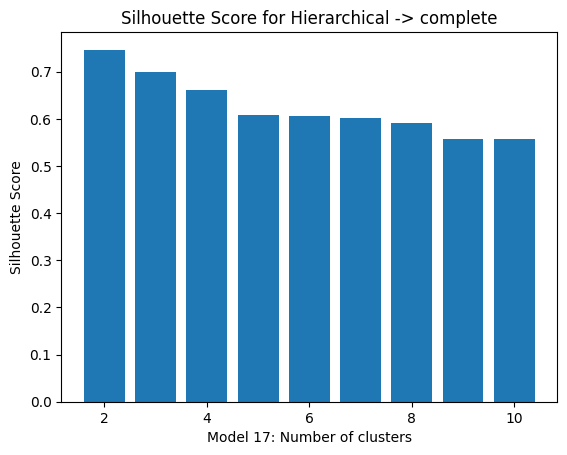

In [178]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_17)
plt.xlabel('Model 17: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> complete')
plt.show()

In [179]:
ac__i_17_final = AgglomerativeClustering(n_clusters = 2, linkage = 'complete')

y_pred_17 = ac__i_17_final.fit_predict(X_scaled_17)

In [180]:
y_pred_17

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

**Model 18**

In [181]:
X_scaled_18 = X_02.copy()

In [182]:
X_scaled_18

array([[67,  2,  1],
       [22,  1,  1],
       [49,  1,  2],
       ...,
       [38,  1,  1],
       [23,  1,  1],
       [27,  1,  1]], shape=(1000, 3))

In [183]:
# Perform hierarchical/agglomerative clustering
Z_18 = shc.linkage(X_scaled_18, 
                   method = 'complete')  # default 
Z_18 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 5.60000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99300000e+03, 1.99400000e+03, 2.60384331e+01, 8.14000000e+02],
       [1.99200000e+03, 1.99500000e+03, 2.90344623e+01, 1.86000000e+02],
       [1.99600000e+03, 1.99700000e+03, 5.60089279e+01, 1.00000000e+03]],
      shape=(999, 4))

In [184]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_18 = []

for i in k_range:
    ac_i_18 = AgglomerativeClustering(n_clusters = i, linkage = 'complete')
    silhouette_scores_18.append(silhouette_score(X_scaled_18, ac_i_18.fit_predict(X_scaled_18)))

In [185]:
silhouette_scores_18

[0.6236002058945159,
 0.5647529496428998,
 0.5310505420584293,
 0.525318678046319,
 0.5246730093351492,
 0.4868231786456089,
 0.4854032161590974,
 0.4800057123147299,
 0.4838651582125193]

In [186]:
best_k_18 = k_range[silhouette_scores_18.index(max(silhouette_scores_18))]
print("Best k:", best_k_18)

Best k: 2


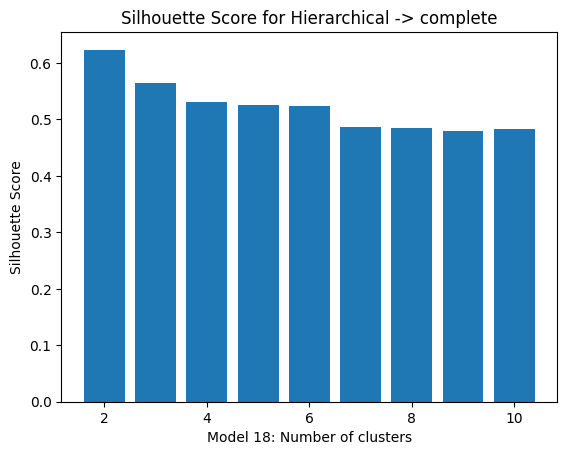

In [187]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_18)
plt.xlabel('Model 18: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> complete')
plt.show()

**Model 19**

In [188]:
X_scaled_19 = X_03.copy()

In [189]:
X_scaled_19

array([[   6, 1169,   67],
       [  48, 5951,   22],
       [  12, 2096,   49],
       ...,
       [  12,  804,   38],
       [  45, 1845,   23],
       [  45, 4576,   27]], shape=(1000, 3))

In [190]:
# Perform hierarchical/agglomerative clustering
Z_19 = shc.linkage(X_scaled_19, 
                   method = 'complete')  # default 
Z_19 # A condensed distance matrix

array([[1.61000000e+02, 5.80000000e+02, 1.00000000e+00, 2.00000000e+00],
       [7.85000000e+02, 8.76000000e+02, 1.41421356e+00, 2.00000000e+00],
       [7.10000000e+01, 8.23000000e+02, 1.73205081e+00, 2.00000000e+00],
       ...,
       [1.99100000e+03, 1.99300000e+03, 7.03300512e+03, 1.42000000e+02],
       [1.99400000e+03, 1.99600000e+03, 1.24810288e+04, 1.55000000e+02],
       [1.99500000e+03, 1.99700000e+03, 1.81740508e+04, 1.00000000e+03]],
      shape=(999, 4))

In [191]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_19 = []

for i in k_range:
    ac_i_19 = AgglomerativeClustering(n_clusters = i, linkage = 'complete')
    silhouette_scores_19.append(silhouette_score(X_scaled_19, ac_i_19.fit_predict(X_scaled_19)))

In [192]:
silhouette_scores_19

[0.7221967415520961,
 0.6964426733613527,
 0.6672265398158915,
 0.5796987572876837,
 0.5787979779356833,
 0.5739961504261452,
 0.5584084179572094,
 0.5580680658791557,
 0.5416523563228911]

In [193]:
best_k_19 = k_range[silhouette_scores_19.index(max(silhouette_scores_19))]
print("Best k:", best_k_19)

Best k: 2


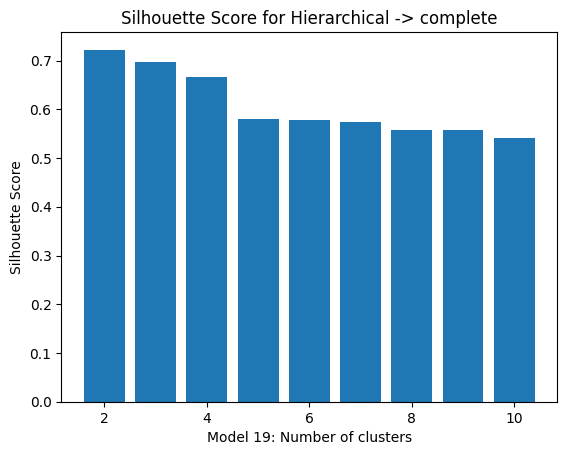

In [194]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_19)
plt.xlabel('Model 19: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> complete')
plt.show()

In [195]:
ac__i_19_final = AgglomerativeClustering(n_clusters = 2, linkage = 'complete')

y_pred_19 = ac__i_19_final.fit_predict(X_scaled_19)

In [196]:
y_pred_19

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,

**Model 20**

In [197]:
X_scaled_20 = X_04.copy()

In [198]:
X_scaled_20

array([[67,  2],
       [22,  1],
       [49,  1],
       ...,
       [38,  1],
       [23,  1],
       [27,  1]], shape=(1000, 2))

In [199]:
# Perform hierarchical/agglomerative clustering
Z_20 = shc.linkage(X_scaled_20, 
                   method = 'complete')  # default 
Z_20 # A condensed distance matrix

array([[0.00000000e+00, 5.54000000e+02, 0.00000000e+00, 2.00000000e+00],
       [1.00000000e+00, 1.20000000e+01, 0.00000000e+00, 2.00000000e+00],
       [2.00000000e+00, 2.77000000e+02, 0.00000000e+00, 2.00000000e+00],
       ...,
       [1.99000000e+03, 1.99400000e+03, 2.70185122e+01, 8.27000000e+02],
       [1.99300000e+03, 1.99500000e+03, 2.90172363e+01, 1.73000000e+02],
       [1.99600000e+03, 1.99700000e+03, 5.60089279e+01, 1.00000000e+03]],
      shape=(999, 4))

In [200]:
# We would like to evaluate the Silhouette Scores for different K, i.e. n_clusters (ranging from 2 to 11)
k_range = range(2, 11)
silhouette_scores_20 = []

for i in k_range:
    ac_i_20 = AgglomerativeClustering(n_clusters = i, linkage = 'complete')
    silhouette_scores_20.append(silhouette_score(X_scaled_20, ac_i_20.fit_predict(X_scaled_20)))

In [201]:
silhouette_scores_20

[0.6214076596358324,
 0.5613881409514684,
 0.49230253983599764,
 0.5040628159815881,
 0.44210412130511245,
 0.4408811489788359,
 0.4831324787828958,
 0.4649147606395042,
 0.48816535362376906]

In [202]:
best_k_20 = k_range[silhouette_scores_20.index(max(silhouette_scores_20))]
print("Best k:", best_k_20)

Best k: 2


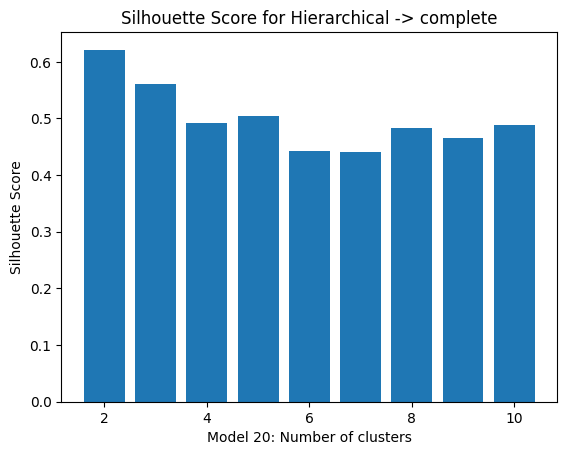

In [203]:
# Plotting Silhouette Scores using a bar graph to compare the results 
plt.bar(k_range, silhouette_scores_20)
plt.xlabel('Model 20: Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Hierarchical -> complete')
plt.show()

**Final Result of K-Mean & Hierarchical**


|Actual| KMean | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |
|------|-------|----------------------------------|----------------|---------------------------------|
| 01   | Kmean | "Duration in month", "Credit amount" |        2       | 0.5801912097451697 |
| 02   | Kmean | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        6       | 0.6002073234036293 |
| 03   | Kmean | "Duration in month", "Credit amount", "Age in years" |        2       | 0.4346161965920348 |
| 04   | Kmean | "Age in years", "Number of existing credits at this bank" |        8       |  0.5862412201715027 |

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 05   | Hierarchical | "Duration in month", "Credit amount" |        2       |  0.5389876442823875 | Ward|
| 06   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        6       |  0.600908986378681 | Ward |
| 07   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.4606601589330235 | Ward |
| 08   | Hierarchical | "Age in years", "Number of existing credits at this bank |        5       |   0.5881274127749511 | Ward |

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 09   | Hierarchical | "Duration in month", "Credit amount"|        2       |  0.6217746575789506 | Average |
| 10   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        2       |  0.628619413638489 | Average |
| 11   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7466770895205375 | Average |
| 12   | Hierarchical | "Age in years", "Number of existing credits at this bank" |        2       |   0.6233747709090849 | Average |

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 13   | Hierarchical | "Duration in month", "Credit amount"|        2       |  0.782247185921756 | Single |
| 14   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        2       |  0.6227829518889962 | Single |
| 15   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7822310431543447 | Single |
| 16   | Hierarchical | "Age in years", "Number of existing credits at this bank" |        2       |   0.6233747709090849 | Single |

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 17   | Hierarchical | "Duration in month", "Credit amount"|        2       |  0.7466977175431723 | Complete |
| 18   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        2       |  0.6236002058945159 | Complete |
| 19   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7221967415520961 | Complete|
| 20   | Hierarchical | "Age in years", "Number of existing credits at this bank" |        2       |   0.6214076596358324 | Complete |

### 2.0 Model Selection

### Model that cluster 0 have value and cluster 1 only 1 number**

**Model 13 & 15**

**Hierarchical -> Linkage = Single**

Feature use: "Duration in month", "Credit amount".

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 13   | Hierarchical | "Duration in month", "Credit amount"|        2       |  0.782247185921756 | Single |
| 15   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7822310431543447 | Single |

**Model 13, 15 result:**  
- Cluster 0 ≈ almost all observations
- Cluster 1 = ONE outlier


### Model that work out well:
**Model 11 & 17**

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 17   | Hierarchical | "Duration in month", "Credit amount"|        2       |  0.7466977175431723 | Complete |
| 11   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7466770895205375 | Average |
| 19   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7221967415520961 | Complete|
| 10   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        2       |  0.628619413638489 | Average |

**Model 11, 17 result:**  
- Cluster 0 has 987 observations
- Cluster 1 has 13 observations

**Model 19 result:**  
- Cluster 0 has 15.5 observations
- Cluster 1 has 84.5 observations

**Model 10 result:**  
- Cluster 0 has 23.3 observations
- Cluster 1 has 76.7 observations

In [204]:
bank_data_13 = bank_data.copy()

In [205]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_13['Cluster'] = y_pred_13

In [206]:
bank_data_13['Cluster'].value_counts(normalize=True) * 100

Cluster
0    99.9
1     0.1
Name: proportion, dtype: float64

In [207]:
bank_data_13.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,0
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,0
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,0


In [208]:
bank_data_15 = bank_data.copy()

In [209]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_15['Cluster'] = y_pred_15

In [210]:
bank_data_15.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,0
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,0
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,0


In [211]:
bank_data_15['Cluster'].value_counts(normalize=True) * 100

Cluster
0    99.9
1     0.1
Name: proportion, dtype: float64

In [212]:
bank_data_11 = bank_data.copy()

In [213]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_11['Cluster'] = y_pred_11

In [214]:
bank_data_11.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,0
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,0
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,0


In [215]:
bank_data_11['Cluster'].value_counts(normalize=True) * 100

Cluster
0    98.7
1     1.3
Name: proportion, dtype: float64

In [216]:
bank_data_17 = bank_data.copy()

In [217]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_17['Cluster'] = y_pred_17

In [218]:
bank_data_17.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,0
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,0
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,0


In [219]:
bank_data_17['Cluster'].value_counts(normalize=True) * 100

Cluster
0    98.7
1     1.3
Name: proportion, dtype: float64

In [220]:
bank_data_19 = bank_data.copy()

In [221]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_19['Cluster'] = y_pred_19

In [222]:
bank_data_19.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,1
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,1
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,1


In [223]:
bank_data_19['Cluster'].value_counts(normalize=True) * 100

Cluster
1    84.5
0    15.5
Name: proportion, dtype: float64

In [224]:
bank_data_10 = bank_data.copy()

In [225]:
# Create a name column "Cluster" in original dataframe (bank_data)
bank_data_10['Cluster'] = y_pred_10

In [226]:
bank_data_10.head(10)

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,0
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,1
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,0
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,0
5,No Checking account,36,existing credits paid back duly till now,education,9055,Savings account,1 - 4 years,2,male : single,none,...,35,none,for free,1,unskilled - resident,2,"yes, registered under the customers name",yes,1,1
6,No Checking account,24,existing credits paid back duly till now,furniture/equipment,2835,Savings account,> 7 years,3,male : single,none,...,53,none,own,1,skilled employee / official,1,NaN,yes,1,0
7,Salary assignments for at least 2 year,36,existing credits paid back duly till now,car(used),6948,Savings account,1 - 4 years,2,male : single,none,...,35,none,rent,1,management/ self-employed/\nhighly qualified e...,1,"yes, registered under the customers name",yes,1,1
8,No Checking account,12,existing credits paid back duly till now,radio/television,3059,Savings account,4- 7 years,2,male : divorced/separated,none,...,61,none,own,1,unskilled - resident,1,NaN,yes,1,0
9,Salary assignments for at least 2 year,30,critical account/ other credits existing (not ...,car(new),5234,Savings account,unemployed,4,male : married/widowed,none,...,28,none,own,2,management/ self-employed/\nhighly qualified e...,1,NaN,yes,2,1


In [227]:
bank_data_10['Cluster'].value_counts(normalize=True) * 100

Cluster
1    76.7
0    23.3
Name: proportion, dtype: float64

Duration in month


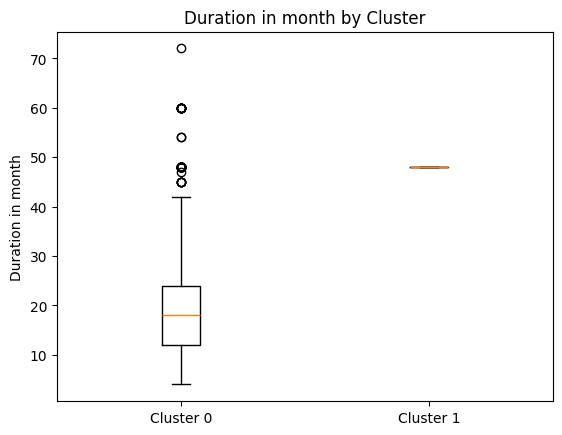

Credit amount


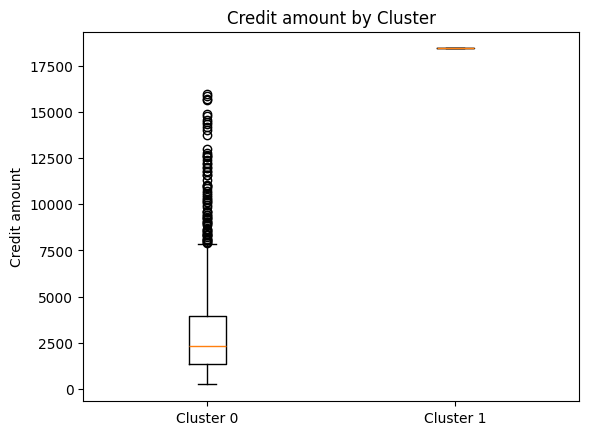

Instalment rate in percentage of disposable income


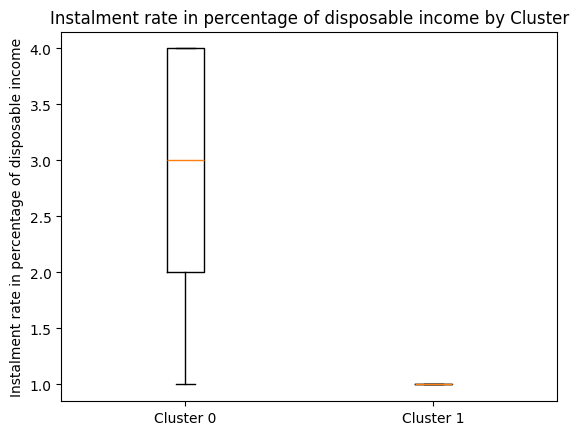

Present residence since


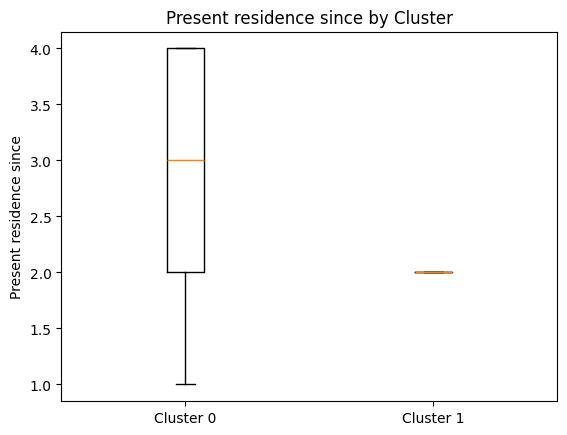

Age in years


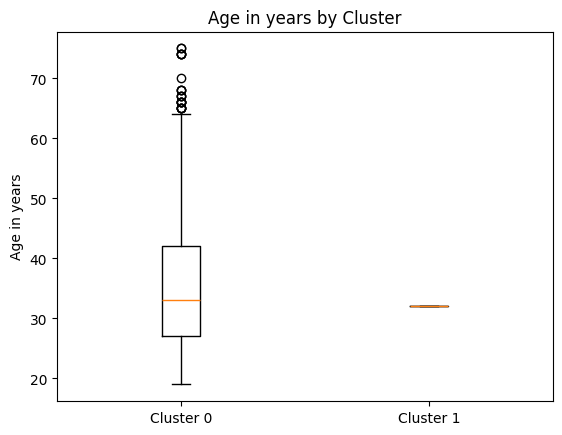

Number of existing credits at this bank


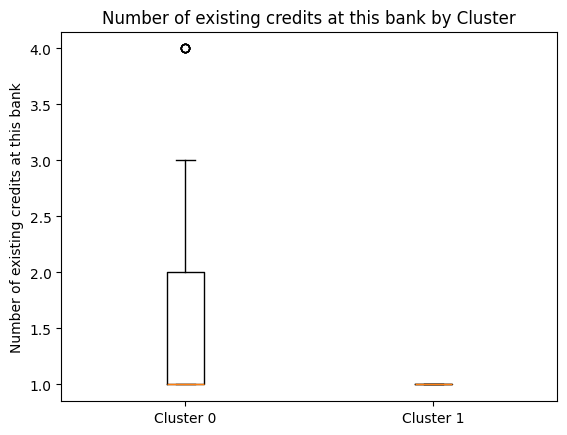

Number of people being liable to provide maintenance for


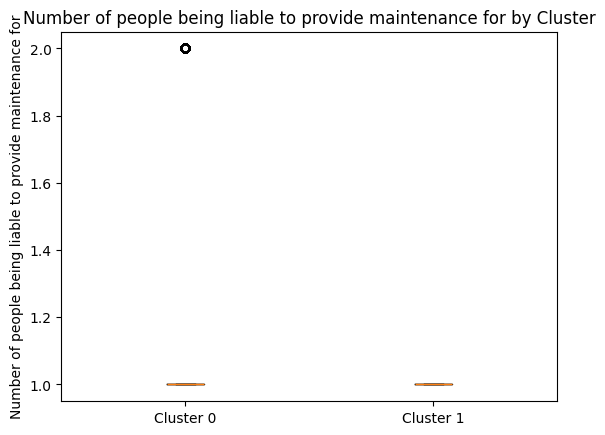

Target


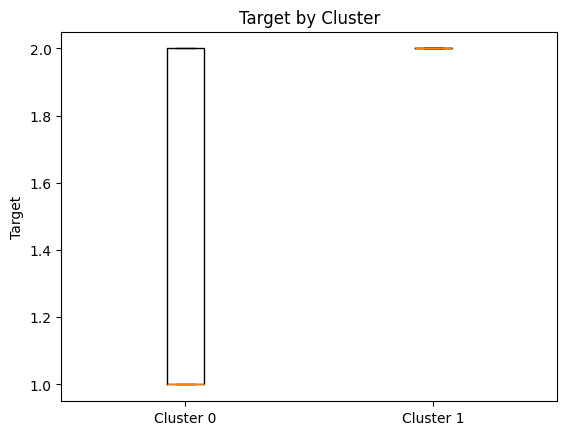

In [228]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_13.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_13.loc[bank_data_13.Cluster == 0, col],
            bank_data_13.loc[bank_data_13.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

Duration in month


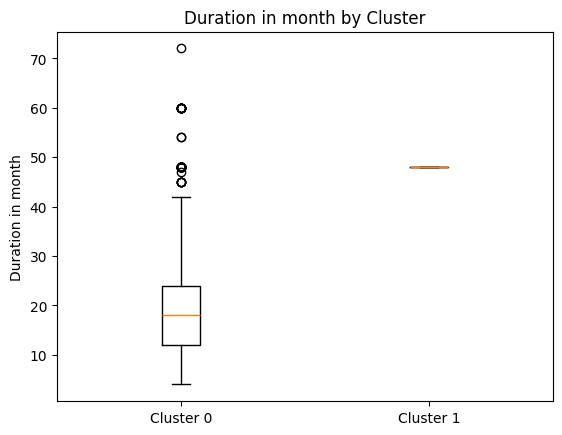

Credit amount


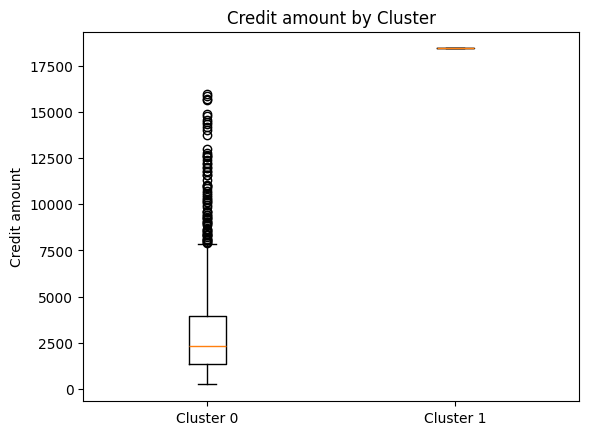

Instalment rate in percentage of disposable income


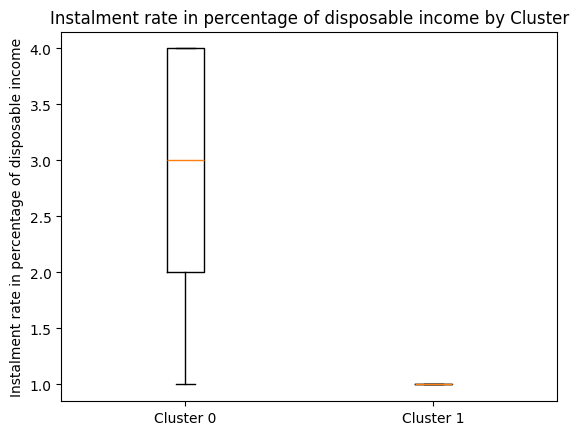

Present residence since


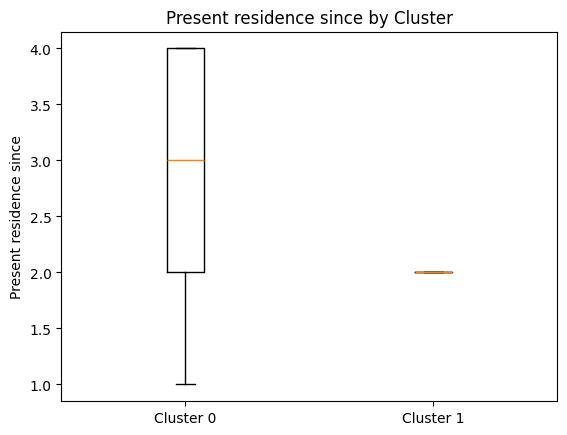

Age in years


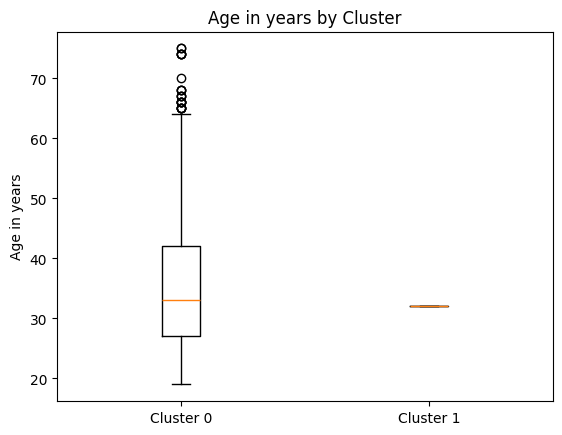

Number of existing credits at this bank


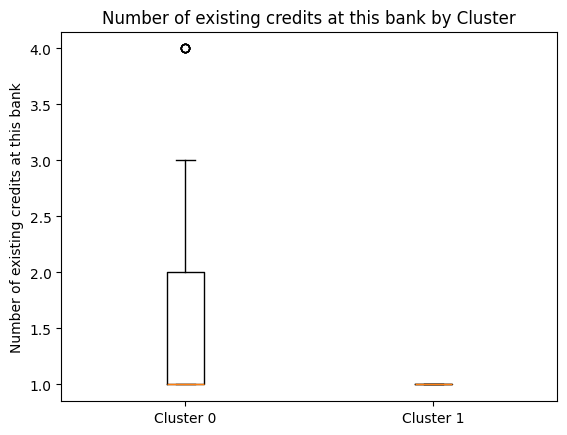

Number of people being liable to provide maintenance for


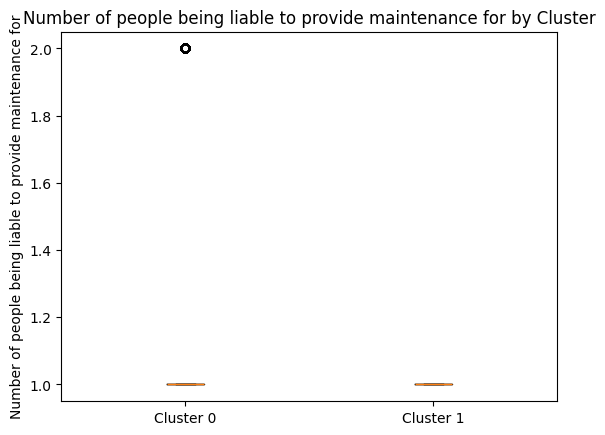

Target


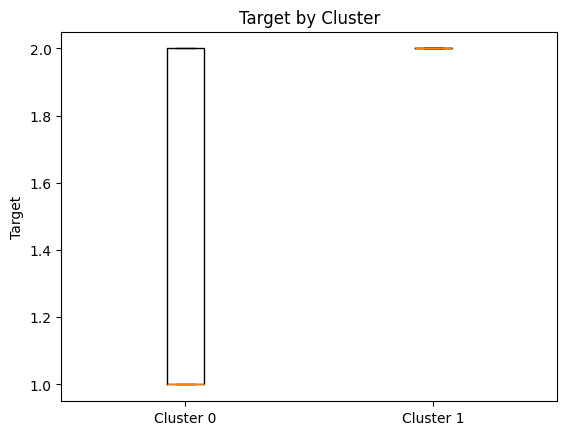

In [229]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_15.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_15.loc[bank_data_13.Cluster == 0, col],
            bank_data_15.loc[bank_data_13.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

Duration in month


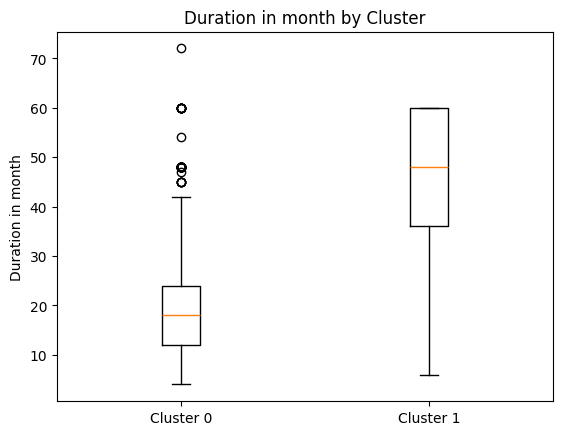

Credit amount


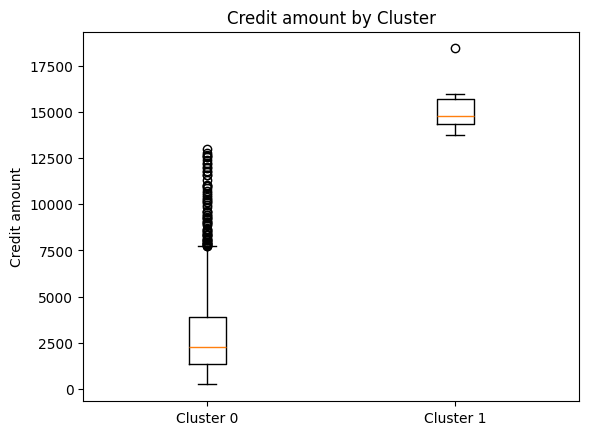

Instalment rate in percentage of disposable income


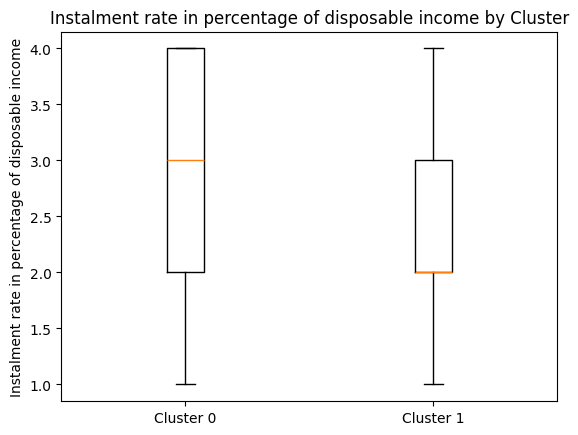

Present residence since


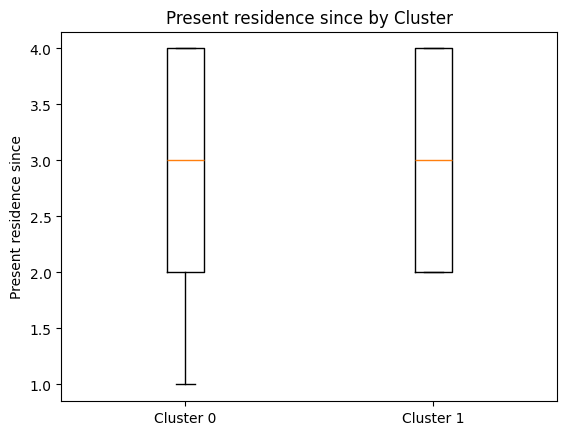

Age in years


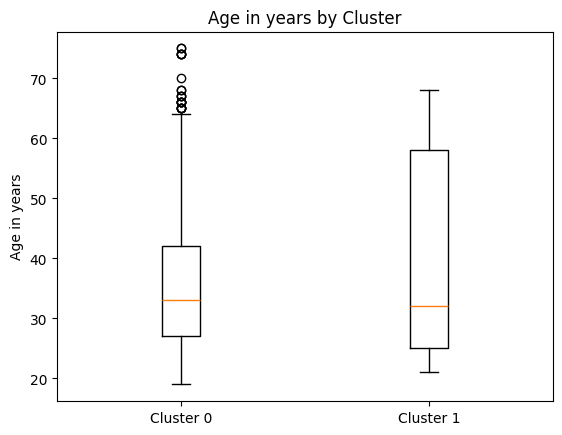

Number of existing credits at this bank


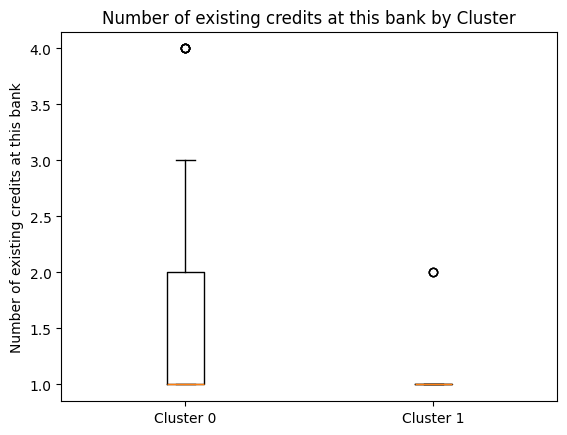

Number of people being liable to provide maintenance for


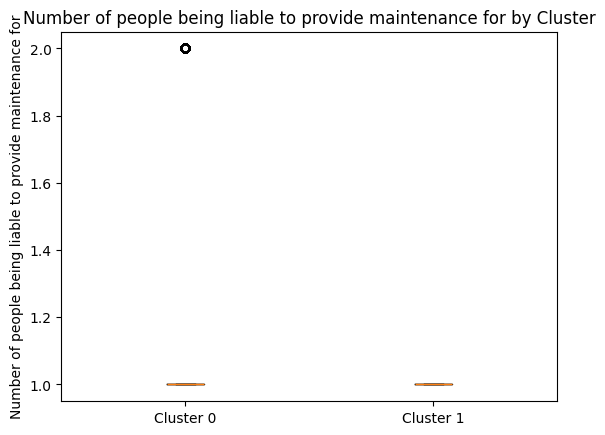

Target


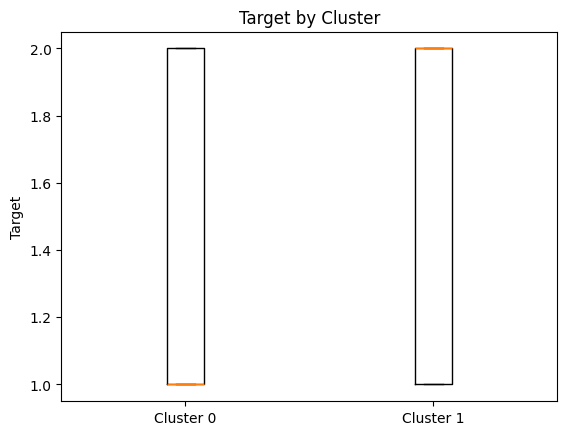

In [230]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_11.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_11.loc[bank_data_11.Cluster == 0, col],
            bank_data_11.loc[bank_data_11.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

Duration in month


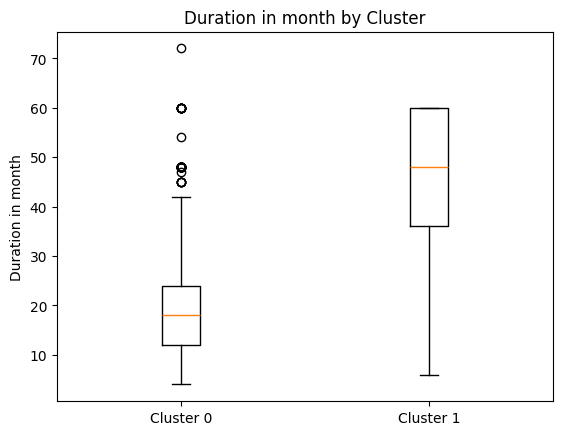

Credit amount


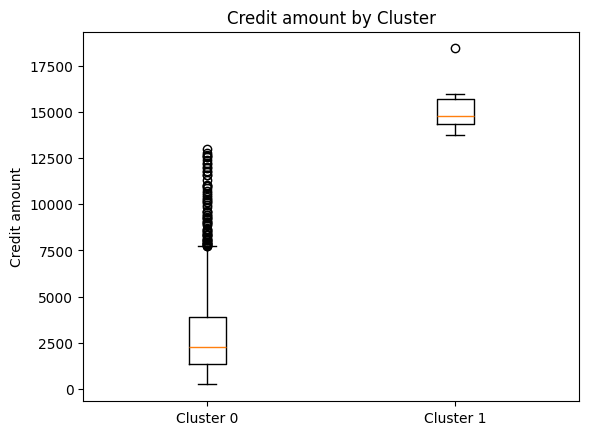

Instalment rate in percentage of disposable income


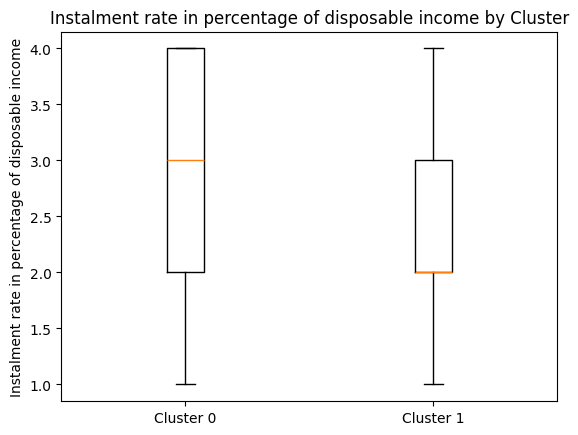

Present residence since


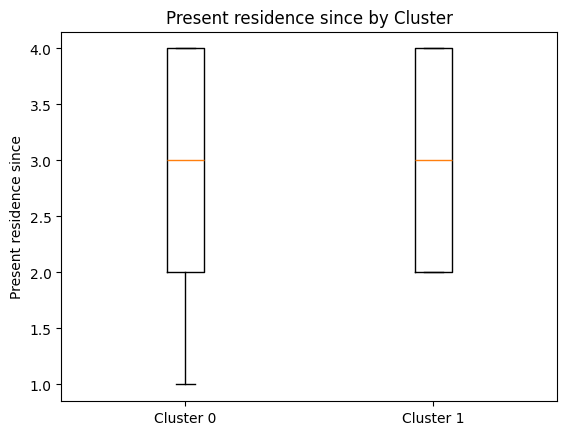

Age in years


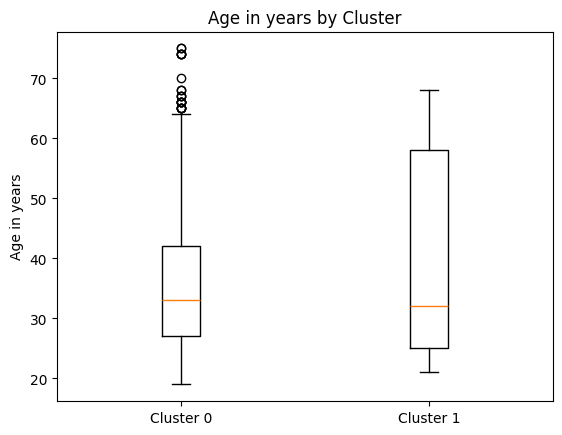

Number of existing credits at this bank


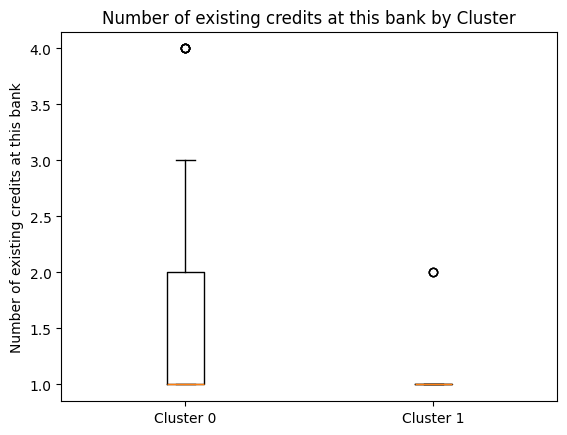

Number of people being liable to provide maintenance for


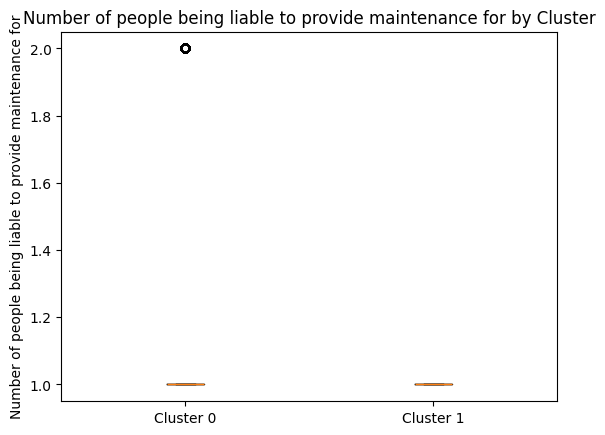

Target


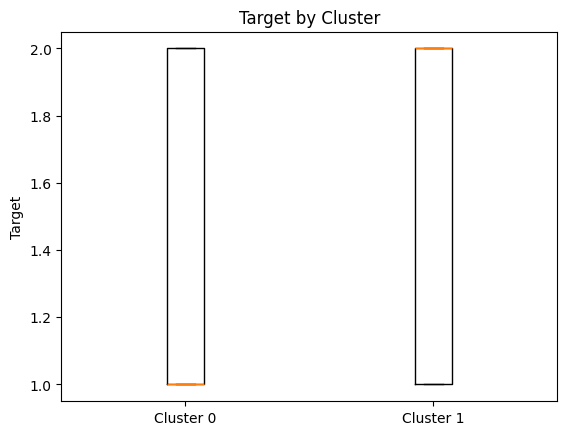

In [231]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_17.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_17.loc[bank_data_17.Cluster == 0, col],
            bank_data_17.loc[bank_data_17.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

Duration in month


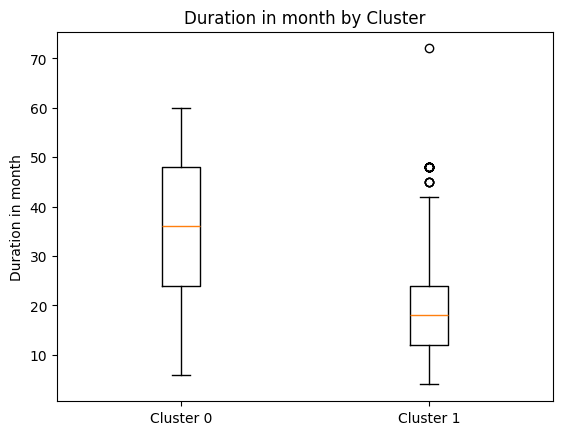

Credit amount


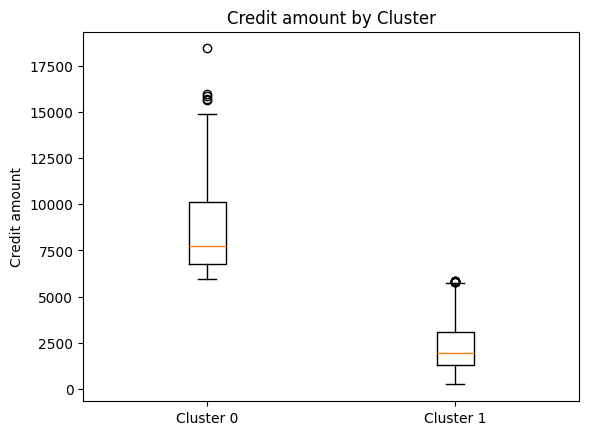

Instalment rate in percentage of disposable income


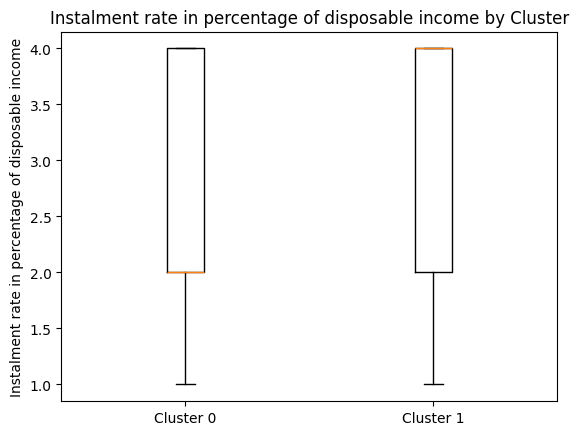

Present residence since


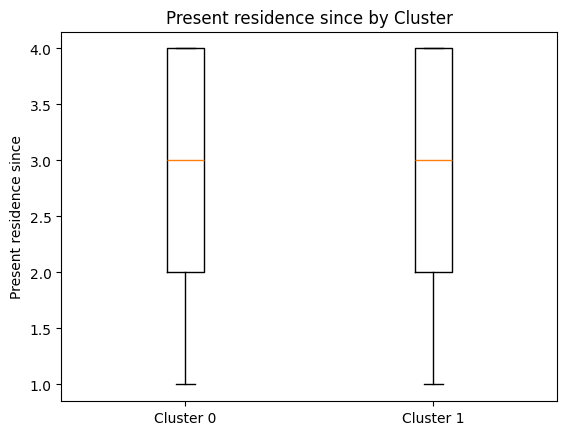

Age in years


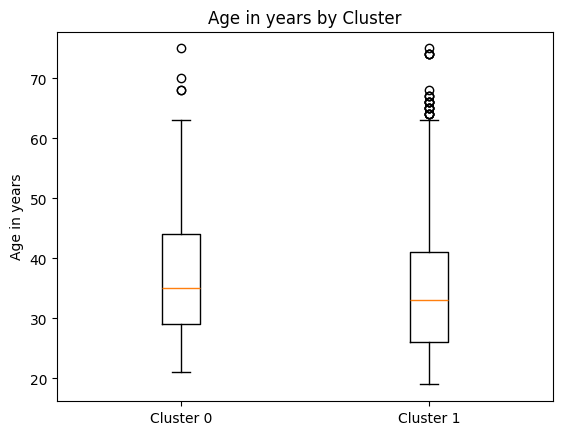

Number of existing credits at this bank


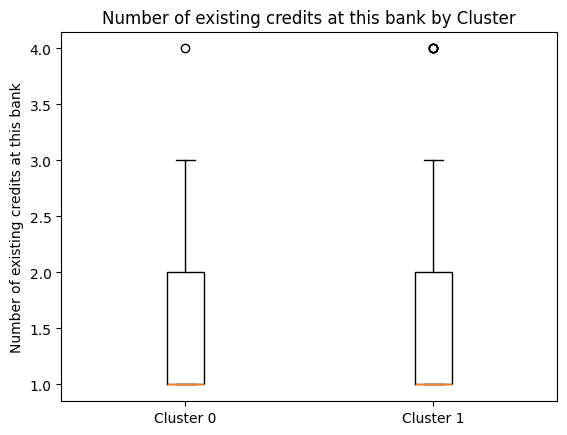

Number of people being liable to provide maintenance for


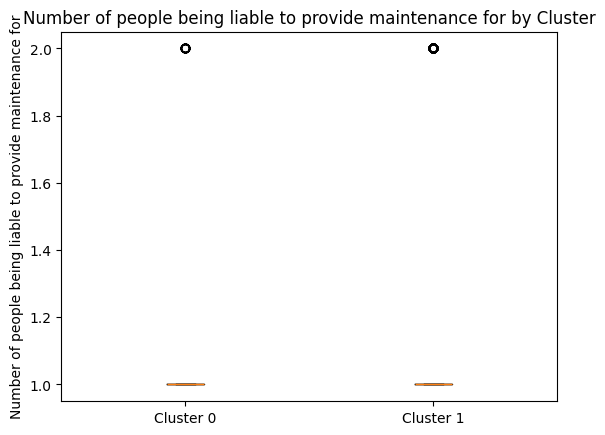

Target


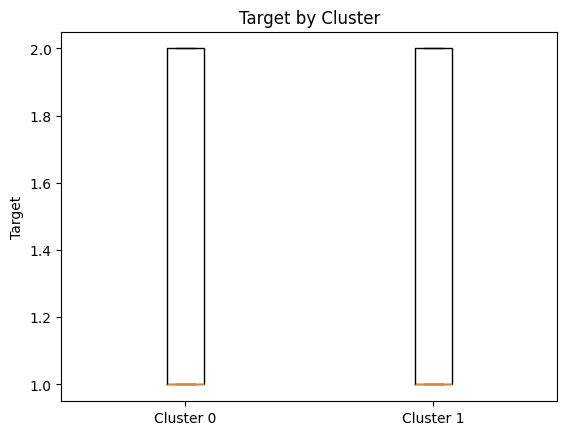

In [232]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_19.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_19.loc[bank_data_19.Cluster == 0, col],
            bank_data_19.loc[bank_data_19.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

Duration in month


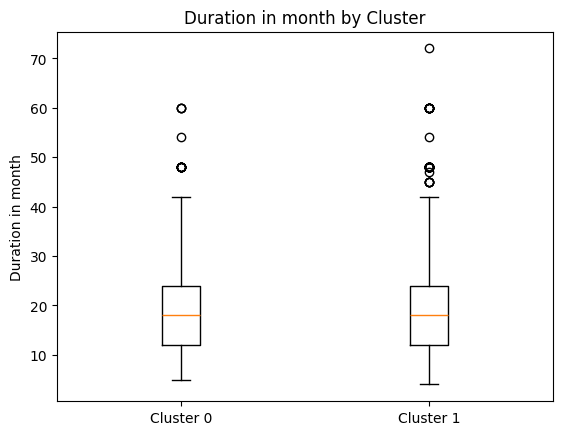

Credit amount


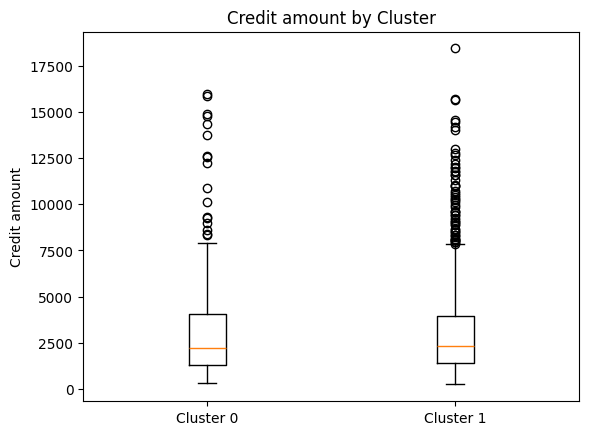

Instalment rate in percentage of disposable income


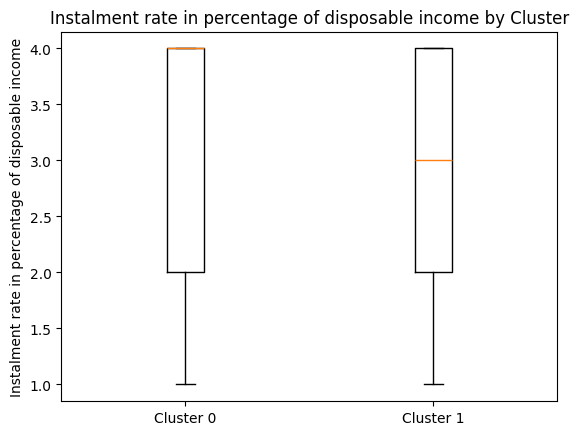

Present residence since


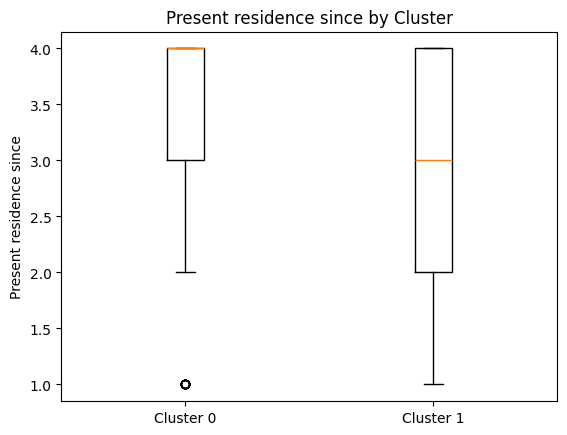

Age in years


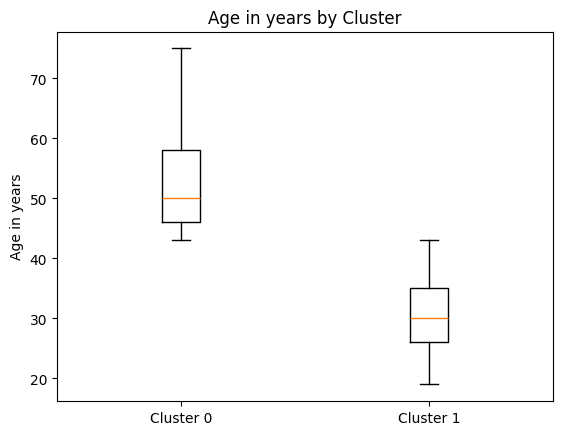

Number of existing credits at this bank


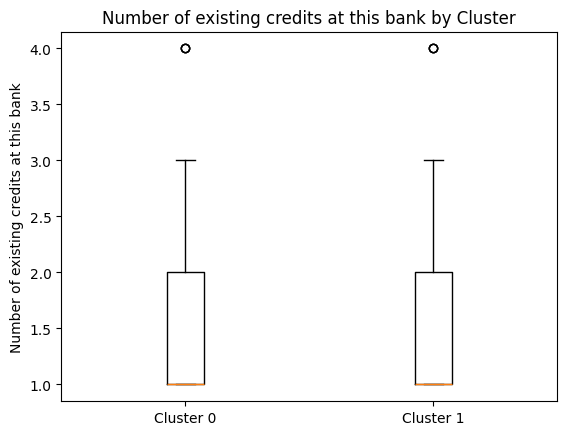

Number of people being liable to provide maintenance for


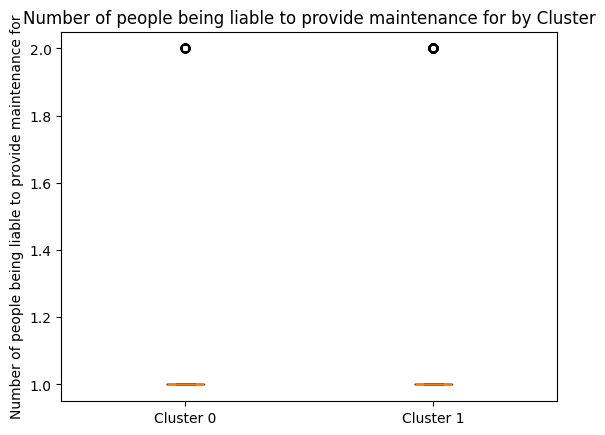

Target


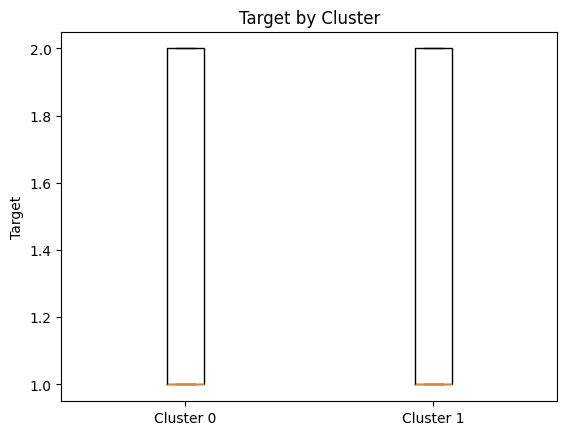

In [233]:
# plot grouped boxplots of each feature for every cluster
numeric_cols = bank_data_10.select_dtypes(include=np.number).columns
numeric_cols = numeric_cols.drop('Cluster')  # don't boxplot the label

for col in numeric_cols:
    print(col)
    plt.cla()
    
    plt.boxplot(
        [
            bank_data_10.loc[bank_data_10.Cluster == 0, col],
            bank_data_10.loc[bank_data_10.Cluster == 1, col]
        ],
        tick_labels=['Cluster 0', 'Cluster 1']
    )
    
    plt.ylabel(col)
    plt.title(f'{col} by Cluster')
    plt.show()

### 2.1 Model Comparison Selection

|Actual| Hierarchical | VarA, VarB, VarC                 |     Cluster    |          Silhouette Score       |Linkage|
|------|--------------|----------------------------------|----------------|---------------------------------|-------|
| 10   | Hierarchical | "Age in years", "Number of existing credits at this bank", "Number of people being liable to provide maintenance for" |        2       |  0.628619413638489 | Average |
| 19   | Hierarchical | "Duration in month", "Credit amount", "Age in years" |        2       | 0.7221967415520961 | Complete|  




    
****  
As it has the highest Silhouette Score and balanced sheet for clustering. 


|  Model 19 |Duration in month | Credit amount | Age in years | Number of existing credits at this bank | Number of people being liable to provide maintenance for |                             
|-----------|------------------|---------------|--------------|-----------------------------------------|-----------------------------------------|
| cluster 0 |      Middle      |     Middle    |    Low       |                  Low                    |               Low                       |
| cluster 1 |       Low        |      Low      |    Low       |                  Low                    |               Low                       |




|  Model 10 |Duration in month | Credit amount | Age in years | Number of existing credits at this bank | Number of people being liable to provide maintenance for |                             
|-----------|------------------|---------------|--------------|-----------------------------------------|-----------------------------------------|
| cluster 0 |       Low        |      Low      |    High      |                  Low                    |               Low                       |
| cluster 1 |       Low        |      Low      |    Low       |                  Low                    |               Low                       |

                        Model 19
                                             Duration in month  , Cluster 0: -> Middle & Cluster 1: <- Low
                                                 Credit amount  , Cluster 0: -> Middle & Cluster 1: <- Low
                                                  Age in years	, Cluster 0: ->   Low  & Cluster 1: <- Low
                       Number of existing credits at this bank  , Cluster 0: ->   Low  & Cluster 1: <- Low
      Number of people being liable to provide maintenance for  , Cluster 0: ->   Low  & Cluster 1: <- Low


                        Model 10
                                             Duration in month  , Cluster 0: ->   Low  & Cluster 1: <- Low
                                                 Credit amount  , Cluster 0: ->   Low  & Cluster 1: <- Low
                                                  Age in years	, Cluster 0: ->   High & Cluster 1: <- Low
                       Number of existing credits at this bank  , Cluster 0: ->   Low  & Cluster 1: <- Low
      Number of people being liable to provide maintenance for  , Cluster 0: ->   Low  & Cluster 1: <- Low

In this diagram show in Model 19:  
- The cluster 0 and cluster 1, 'Age in years' is low and there is no unequal age group in them.
- The Cluster 0, 'Credit amount' is middle while Cluster 1 is low.
- The Cluster 0, 'Duration in month' is middle while Cluster 1 is low.

While, in the diagram show model 10:  
- The cluster 0, 'Age in years' is high while Cluster 1 is low.
- The cluster 0 and cluster 1, 'Credit amount' both are low.
- The cluster 0 and cluster 1, 'Duration in month' both are low.

### 2.1 Model Final Selection

**Model 19**

In [234]:
bank_data_19.head()

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,1
1,Salary assignments for at least 2 year,48,existing credits paid back duly till now,radio/television,5951,Savings account,1 - 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee / official,1,NaN,yes,2,0
2,No Checking account,12,critical account/ other credits existing (not ...,education,2096,Savings account,4- 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,NaN,yes,1,1
3,Salary assignments for at least 1 year,42,existing credits paid back duly till now,furniture/equipment,7882,Savings account,4- 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee / official,2,NaN,yes,1,0
4,Salary assignments for at least 1 year,24,delay in paying off in the past,car(new),4870,Savings account,1 - 4 years,3,male : single,none,...,53,none,for free,2,skilled employee / official,2,NaN,yes,2,1


In [235]:
account_status_model_19 = (bank_data_19.groupby(['Account Status', 'Cluster']).size().reset_index(name = 'count'))

In [236]:
account_status_model_19

,Account Status,Cluster,count
0,No Checking account,0,53
1,No Checking account,1,341
2,Salary assignments for at least 1 year,0,42
3,Salary assignments for at least 1 year,1,232
4,Salary assignments for at least 2 year,0,59
5,Salary assignments for at least 2 year,1,210
6,Salary assignments for at least 3 year,0,1
7,Salary assignments for at least 3 year,1,62


In [237]:
credit_history_model_19 = (bank_data_19.groupby(['Credit History', 'Cluster']).size().reset_index(name = 'count'))

In [238]:
credit_history_model_19

,Credit History,Cluster,count
0,all credits at this bank paid back duly,0,10
1,all credits at this bank paid back duly,1,39
2,critical account/ other credits existing (not ...,0,40
3,critical account/ other credits existing (not ...,1,253
4,delay in paying off in the past,0,27
5,delay in paying off in the past,1,61
6,existing credits paid back duly till now,0,65
7,existing credits paid back duly till now,1,465
8,no credits taken/ all credits paid back duly,0,13
9,no credits taken/ all credits paid back duly,1,27


In [239]:
purpose_model_19 = (bank_data_19.groupby(['Purpose', 'Cluster']).size().reset_index(name = 'count'))

In [240]:
purpose_model_19

,Purpose,Cluster,count
0,business,0,23
1,business,1,74
2,car(new),0,34
3,car(new),1,200
4,car(used),0,41
5,car(used),1,62
6,domestic appliances,1,12
7,education,0,11
8,education,1,39
9,furniture/equipment,0,16


In [241]:
savings_account_bonds_model_19 = (bank_data_19.groupby(['Savings account or bonds', 'Cluster']).size().reset_index(name = 'count'))

In [242]:
savings_account_bonds_model_19

,Savings account or bonds,Cluster,count
0,Savings account,0,155
1,Savings account,1,845


In [243]:
present_employment_since_model_19 = (bank_data_19.groupby(['Present employment since', 'Cluster']).size().reset_index(name = 'count'))

In [244]:
present_employment_since_model_19

,Present employment since,Cluster,count
0,< 1 year,0,21
1,< 1 year,1,151
2,1 - 4 years,0,42
3,1 - 4 years,1,297
4,4- 7 years,0,35
5,4- 7 years,1,139
6,> 7 years,0,40
7,> 7 years,1,213
8,unemployed,0,17
9,unemployed,1,45


In [245]:
personal_status_and_sex_model_19 = (bank_data_19.groupby(['Personal status and sex', 'Cluster']).size().reset_index(name = 'count'))

In [246]:
personal_status_and_sex_model_19

,Personal status and sex,Cluster,count
0,female : divorced/separated/married,0,36
1,female : divorced/separated/married,1,274
2,male : divorced/separated,0,9
3,male : divorced/separated,1,41
4,male : married/widowed,0,6
5,male : married/widowed,1,86
6,male : single,0,104
7,male : single,1,444


In [247]:
other_debtors_or_guarantors_model_19 = (bank_data_19.groupby(['Other debtors or guarantors', 'Cluster']).size().reset_index(name = 'count'))

In [248]:
other_debtors_or_guarantors_model_19

,Other debtors or guarantors,Cluster,count
0,co-applicant,0,10
1,co-applicant,1,31
2,guarantor,0,4
3,guarantor,1,48
4,none,0,141
5,none,1,766


In [249]:
property_model_19 = (bank_data_19.groupby(['Property', 'Cluster']).size().reset_index(name = 'count'))

In [250]:
property_model_19

,Property,Cluster,count
0,building society savings agreement/ life insur...,0,31
1,building society savings agreement/ life insur...,1,201
2,"car or other, not in attribute 6",0,55
3,"car or other, not in attribute 6",1,277
4,real estate,0,14
5,real estate,1,268
6,unknown / no property,0,55
7,unknown / no property,1,99


In [251]:
other_installment_plans_model_19 = (bank_data_19.groupby(['Other installment plans', 'Cluster']).size().reset_index(name = 'count'))

In [252]:
other_installment_plans_model_19

,Other installment plans,Cluster,count
0,bank,0,27
1,bank,1,112
2,none,0,119
3,none,1,695
4,stores,0,9
5,stores,1,38


In [253]:
housing_model_19 = (bank_data_19.groupby(['Housing', 'Cluster']).size().reset_index(name = 'count'))

In [254]:
housing_model_19

,Housing,Cluster,count
0,for free,0,38
1,for free,1,70
2,own,0,91
3,own,1,622
4,rent,0,26
5,rent,1,153


In [255]:
number_of_existing_credits_at_this_bank_model_19 = (bank_data_19.groupby(['Number of existing credits at this bank', 'Cluster']).size().reset_index(name = 'count'))

In [256]:
number_of_existing_credits_at_this_bank_model_19

,Number of existing credits at this bank,Cluster,count
0,1,0,90
1,1,1,543
2,2,0,61
3,2,1,272
4,3,0,3
5,3,1,25
6,4,0,1
7,4,1,5


In [257]:
job_model_19 = (bank_data_19.groupby(['Job', 'Cluster']).size().reset_index(name = 'count'))

In [258]:
job_model_19

,Job,Cluster,count
0,management/ self-employed/\nhighly qualified e...,0,59
1,management/ self-employed/\nhighly qualified e...,1,89
2,skilled employee / official,0,79
3,skilled employee / official,1,551
4,unemployed/ unskilled - non-resident,0,2
5,unemployed/ unskilled - non-resident,1,20
6,unskilled - resident,0,15
7,unskilled - resident,1,185


In [259]:
telephone_model_19 = (bank_data_19.groupby(['Telephone', 'Cluster']).size().reset_index(name = 'count'))

In [260]:
telephone_model_19

,Telephone,Cluster,count
0,"yes, registered under the customers name",0,102
1,"yes, registered under the customers name",1,302


In [261]:
foreign_worker_model_19 = (bank_data_19.groupby(['Foreign worker', 'Cluster']).size().reset_index(name = 'count'))

In [262]:
foreign_worker_model_19

,Foreign worker,Cluster,count
0,no,0,3
1,no,1,34
2,yes,0,152
3,yes,1,811


### Step 2.2 Further Exploration 

In [263]:
account_and_credit_model_19 = (bank_data_19.groupby(['Account Status', 'Credit History', 'Cluster']).size().reset_index(name = 'count'))

In [264]:
account_and_credit_model_19

,Account Status,Credit History,Cluster,count
0,No Checking account,all credits at this bank paid back duly,0,3
1,No Checking account,all credits at this bank paid back duly,1,6
2,No Checking account,critical account/ other credits existing (not ...,0,23
3,No Checking account,critical account/ other credits existing (not ...,1,130
4,No Checking account,delay in paying off in the past,0,10
5,No Checking account,delay in paying off in the past,1,28
6,No Checking account,existing credits paid back duly till now,0,16
7,No Checking account,existing credits paid back duly till now,1,171
8,No Checking account,no credits taken/ all credits paid back duly,0,1
9,No Checking account,no credits taken/ all credits paid back duly,1,6


In [265]:
bank_data_19.head(1)

,Account Status,Duration in month,Credit History,Purpose,Credit amount,Savings account or bonds,Present employment since,Instalment rate in percentage of disposable income,Personal status and sex,Other debtors or guarantors,...,Age in years,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker,Target,Cluster
0,Salary assignments for at least 1 year,6,critical account/ other credits existing (not ...,radio/television,1169,Savings account,> 7 years,4,male : single,none,...,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes,1,1


### Step 3.0 Visualisation

In [266]:
color_pool = ['#AFEEEE',  # Pale Turquoise (Lightest)
              '#7FFFD4',  # Aquamarine (Light)
              '#40E0D0',  # Turquoise (Standard)
              '#00CED1',  # Dark Turquoise (Medium Dark)
              '#008B8B',  # Dark Cyan (Darkest)
              '#20B2AA',  # Light Sea Green
              '#48D1CC',  # Medium Turquoise
              '#00FFFF',  # Cyan / Aqua
              '#66CDAA',  # Medium Aquamarine
              '#5F9EA0',  # Cadet Blue (muted turquoise)
              '#2E8B57',  # Sea Green (borderline turquoise)
              '#DC143C',  # Crimson
              '#FFD700',  # Gold
              '#800080',  # Purple
              '#8B4513',  # Brown
              '#EE82EE',  # Violet
              '#FFD301',  # Mustard Yellow
              '#005AD9',  # Royal Blue
              '#FF2400',  # Scarlet Red
              '#013220',  # Dark Green
              '#FFE5E5',  # Light Red
              '#FFC0CB',  # Pink
              '#FFB6C1',  # Light Pink
              '#FF7F7F',  # Light Coral Red
              '#FF6347',  # Tomato
              '#FF0000',  # Red
              '#B22222',  # Firebrick
              '#8B0000',  # Dark Red
              '#F2E6FF',  # Lavender Mist
              '#E6CCFF',  # Light Lavender
              '#D8BFD8',  # Thistle
              '#DA70D6',  # Orchid
              '#BA55D3',  # Medium Orchid
              '#9370DB',  # Medium Purple
              '#8A2BE2',  # Blue Violet
              '#4B0082']   # Indigo (Dark Purple)

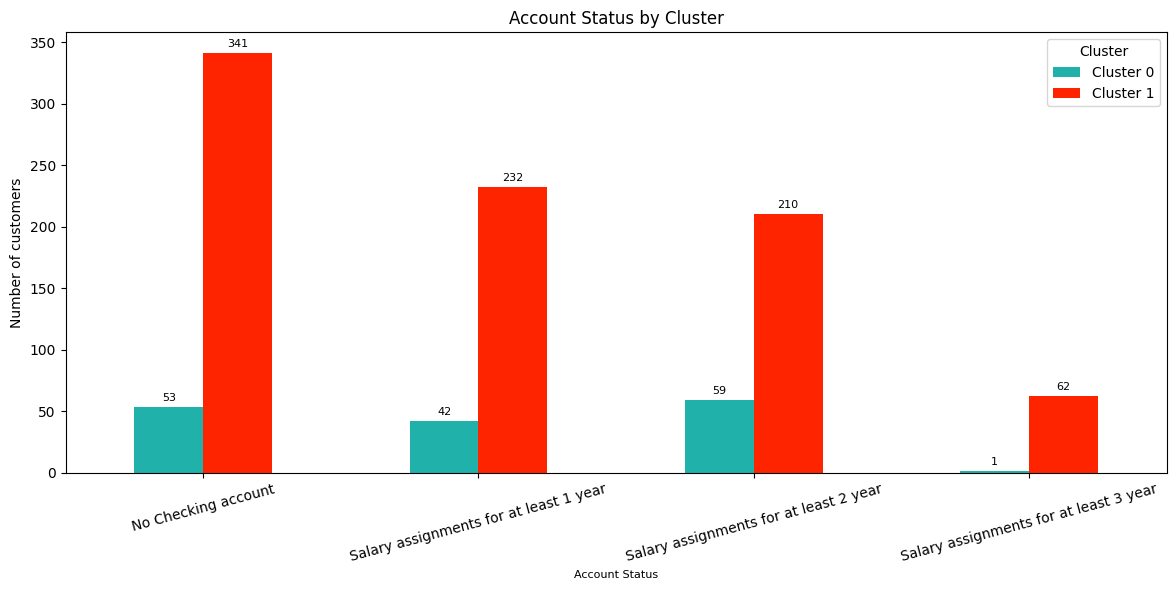

In [267]:
account_status_pivot = account_status_model_19.pivot(index = 'Account Status',
                                                     columns = 'Cluster',
                                                     values = 'count')

account_status_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(account_status_pivot.columns))

# plot side-by-side bars
ax = account_status_pivot.plot(kind = 'bar',
                               figsize = (12, 6),   # width, height)
                               color = random_colors)

plt.ylabel('Number of customers', fontsize = 10)
plt.xlabel('Account Status', fontsize = 8)
plt.title('Account Status by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')
plt.xticks(rotation = 15)   # or 45
# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8, padding=3)


plt.tight_layout()
plt.show()

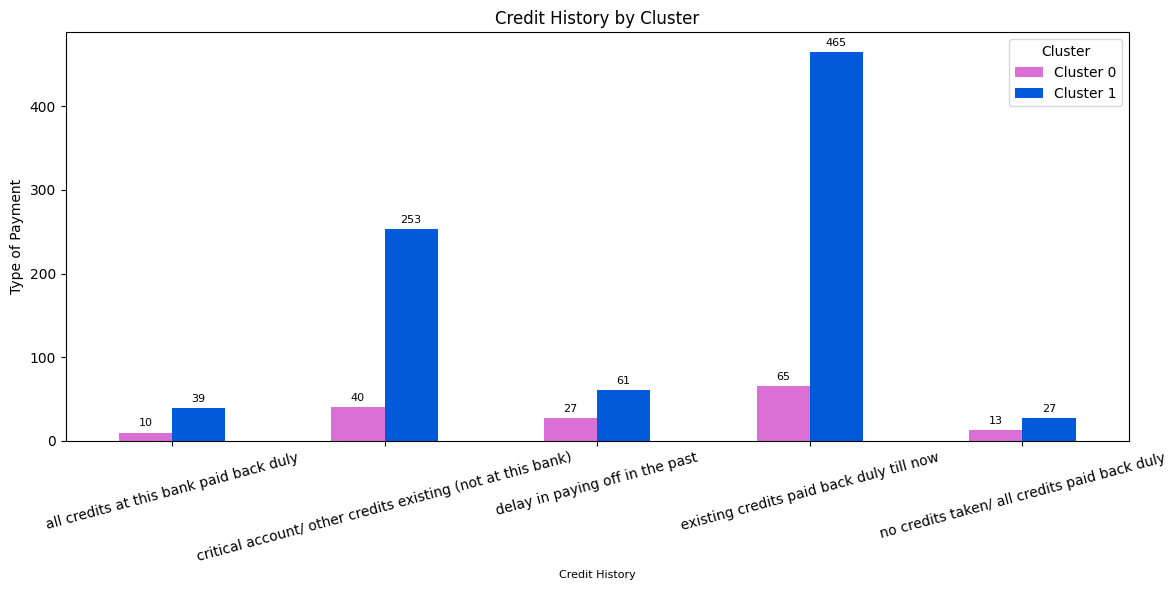

In [268]:
credit_history_pivot = credit_history_model_19.pivot(index = 'Credit History',
                                                     columns = 'Cluster',
                                                     values = 'count')

credit_history_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(credit_history_pivot.columns))

# plot side-by-side bars
ax = credit_history_pivot.plot(kind='bar',
                               figsize = (12, 6),   # width, height
                               color = random_colors)

# 3. Clean up labels (removed \t)
plt.ylabel('Type of Payment', fontsize = 10)
plt.xlabel('Credit History', fontsize = 8)
plt.title('Credit History by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

plt.xticks(rotation = 15)   # or 45
# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

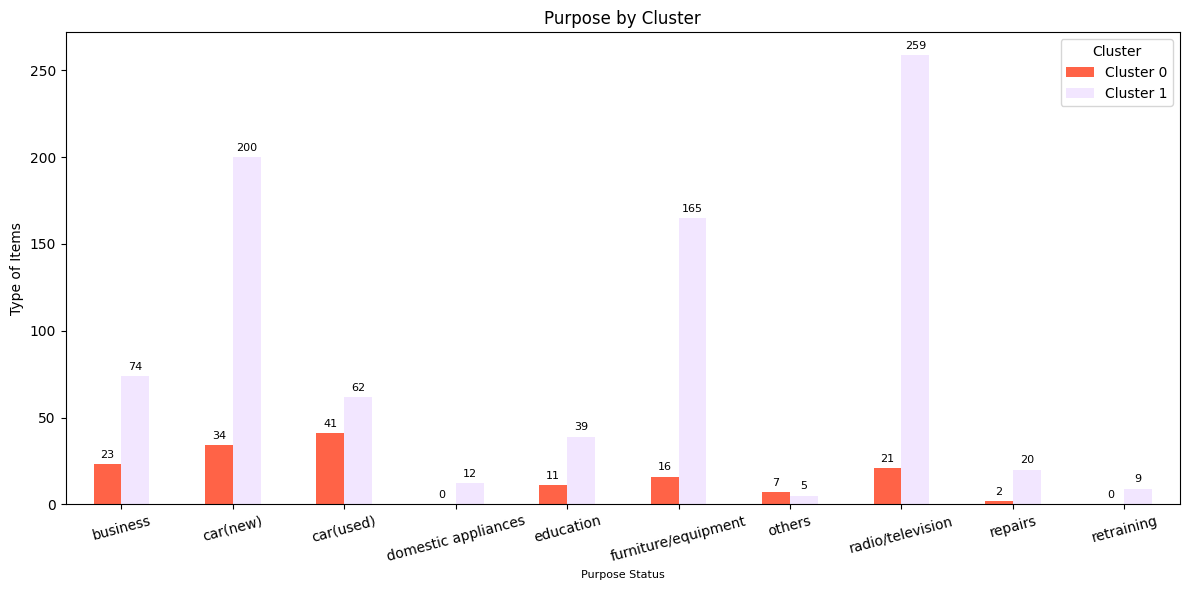

In [269]:
purpose_pivot = purpose_model_19.pivot(index = 'Purpose',
                                       columns = 'Cluster',
                                       values = 'count')

purpose_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(purpose_pivot.columns))

# plot side-by-side bars
ax = purpose_pivot.plot(kind='bar',
                        figsize = (12, 6),   # width, height
                        color = random_colors)

plt.ylabel('Type of Items', fontsize = 10)
plt.xlabel('Purpose Status', fontsize = 8)
plt.title('Purpose by Cluster', fontsize = 12)
plt.legend(title='Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

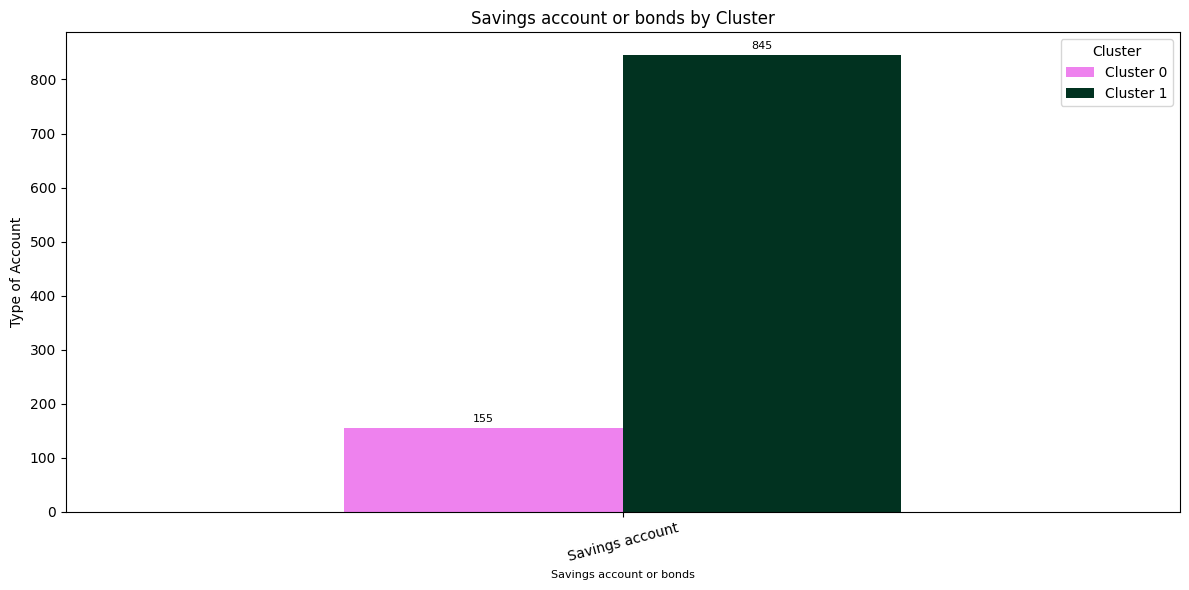

In [270]:
savings_account_bonds_pivot = savings_account_bonds_model_19.pivot(index = 'Savings account or bonds',
                                                                   columns = 'Cluster',
                                                                   values = 'count')

savings_account_bonds_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(savings_account_bonds_pivot.columns))

# plot side-by-side bars
ax = savings_account_bonds_pivot.plot(kind = 'bar',
                                 figsize = (12, 6),   # width, height
                                 color = random_colors)

plt.ylabel('Type of Account', fontsize = 10)
plt.xlabel('Savings account or bonds', fontsize = 8)
plt.title('Savings account or bonds by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

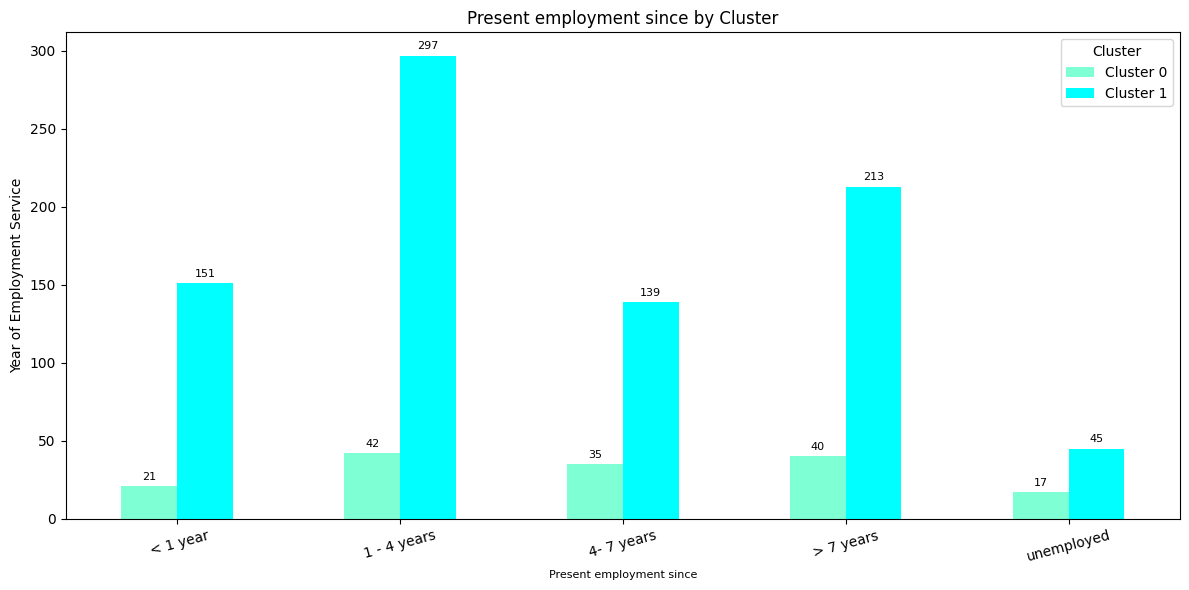

In [271]:
present_employment_since_pivot = present_employment_since_model_19.pivot(index = 'Present employment since',
                                                                         columns = 'Cluster',
                                                                         values = 'count')

present_employment_since_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(present_employment_since_pivot.columns))

# plot side-by-side bars
ax = present_employment_since_pivot.plot(kind = 'bar',
                                    figsize = (12, 6),   # width, height
                                    color = random_colors)

plt.ylabel('Year of Employment Service', fontsize = 10)
plt.xlabel('Present employment since', fontsize = 8)
plt.title('Present employment since by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)


plt.tight_layout()
plt.show()

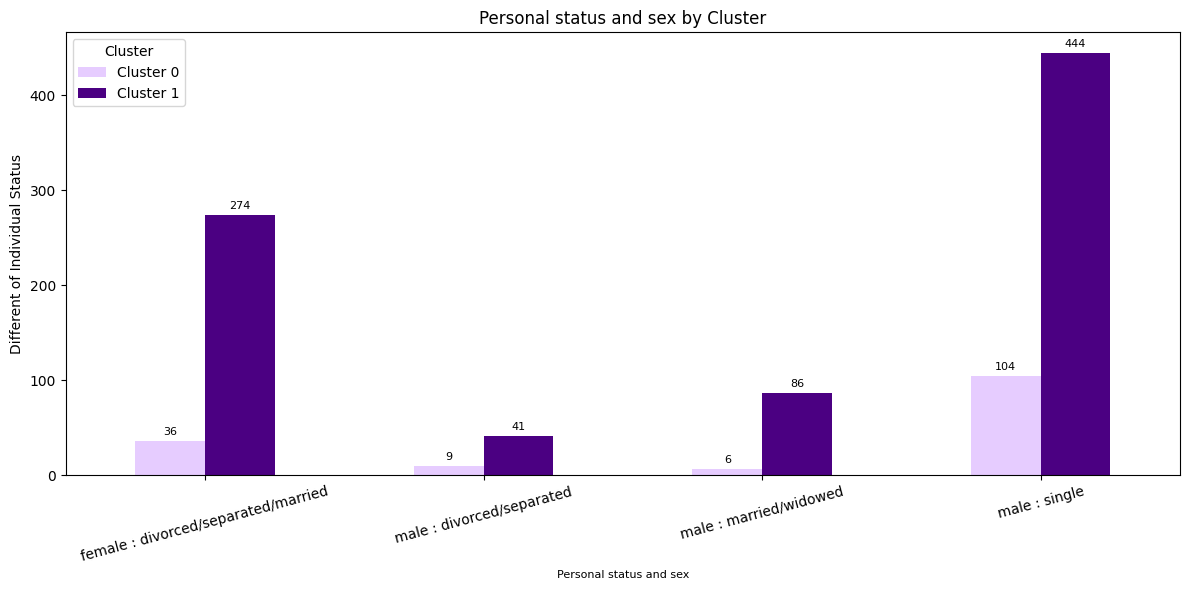

In [272]:
personal_status_and_sex_pivot = personal_status_and_sex_model_19.pivot(index = 'Personal status and sex',
                                                                       columns = 'Cluster',
                                                                       values = 'count')

personal_status_and_sex_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(personal_status_and_sex_pivot.columns))

# plot side-by-side bars
ax = personal_status_and_sex_pivot.plot(kind = 'bar',
                                        figsize = (12, 6),   # width, height
                                        color = random_colors)

plt.ylabel('Different of Individual Status', fontsize = 10)
plt.xlabel('Personal status and sex', fontsize = 8)
plt.title('Personal status and sex by Cluster', fontsize = 12)
plt.legend(title='Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

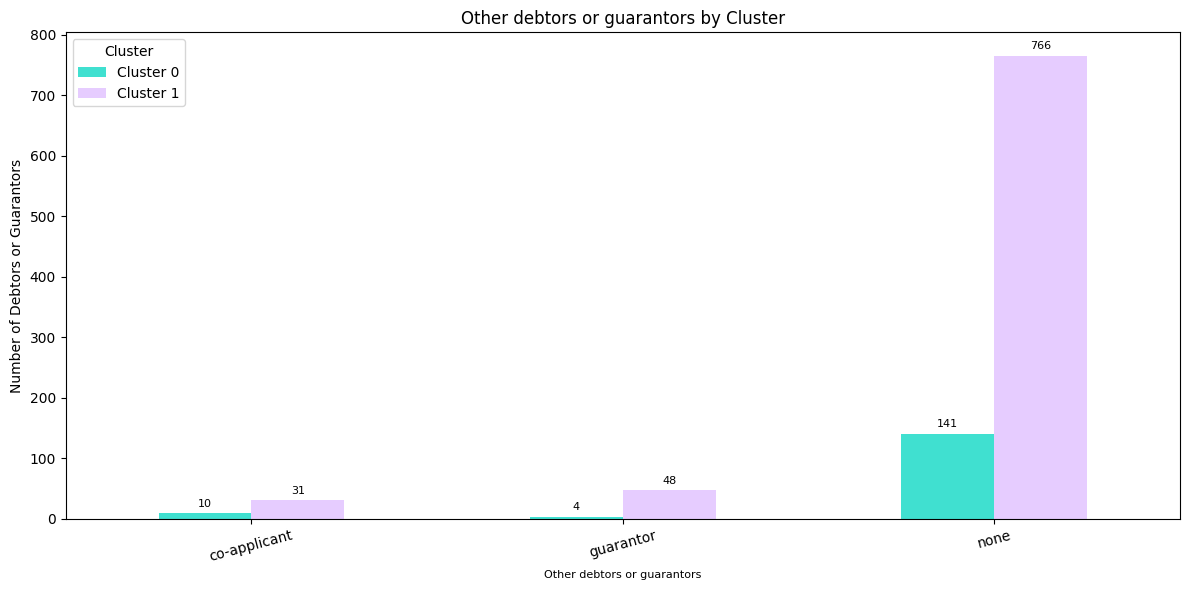

In [273]:
other_debtors_or_guarantors_pivot = other_debtors_or_guarantors_model_19.pivot(index = 'Other debtors or guarantors',
                                                                               columns = 'Cluster',
                                                                               values = 'count')

other_debtors_or_guarantors_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(other_debtors_or_guarantors_pivot.columns))

# plot side-by-side bars
ax = other_debtors_or_guarantors_pivot.plot(kind = 'bar',
                                            figsize = (12, 6),   # width, height
                                            color = random_colors)

plt.ylabel('Number of Debtors or Guarantors', fontsize = 10)
plt.xlabel('Other debtors or guarantors', fontsize = 8)
plt.title('Other debtors or guarantors by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

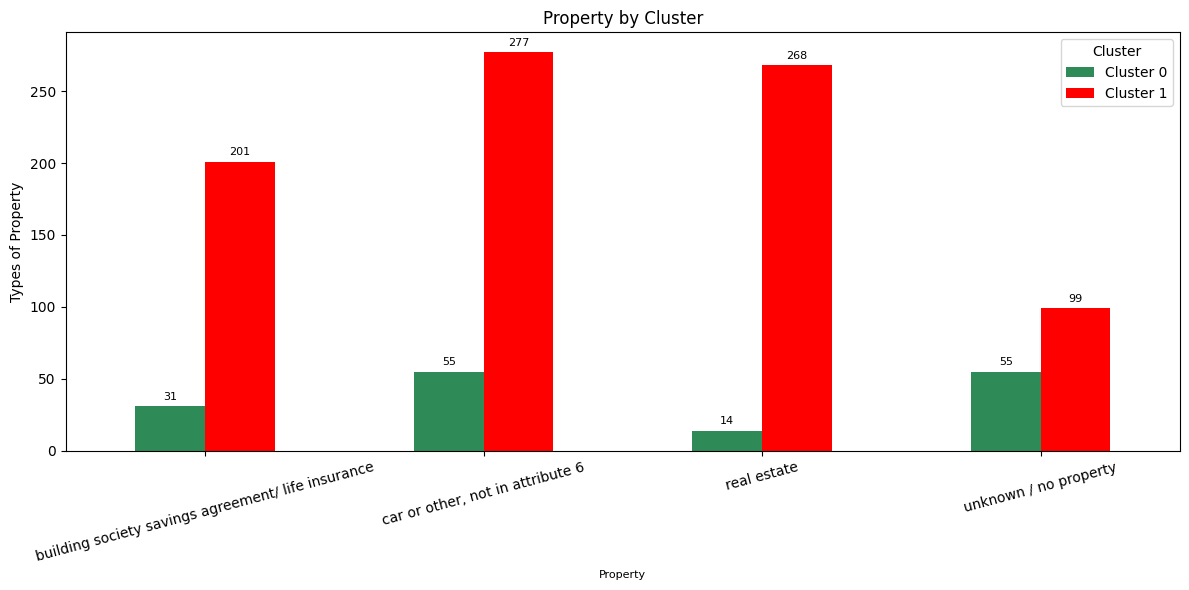

In [274]:
property_pivot = property_model_19.pivot(index = 'Property',
                                         columns = 'Cluster',
                                         values = 'count')

property_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(property_pivot.columns))

# plot side-by-side bars
ax = property_pivot.plot(kind = 'bar',
                         figsize = (12, 6),   # width, height
                         color = random_colors)

plt.ylabel('Types of Property', fontsize = 10)
plt.xlabel('Property', fontsize = 8)
plt.title('Property by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

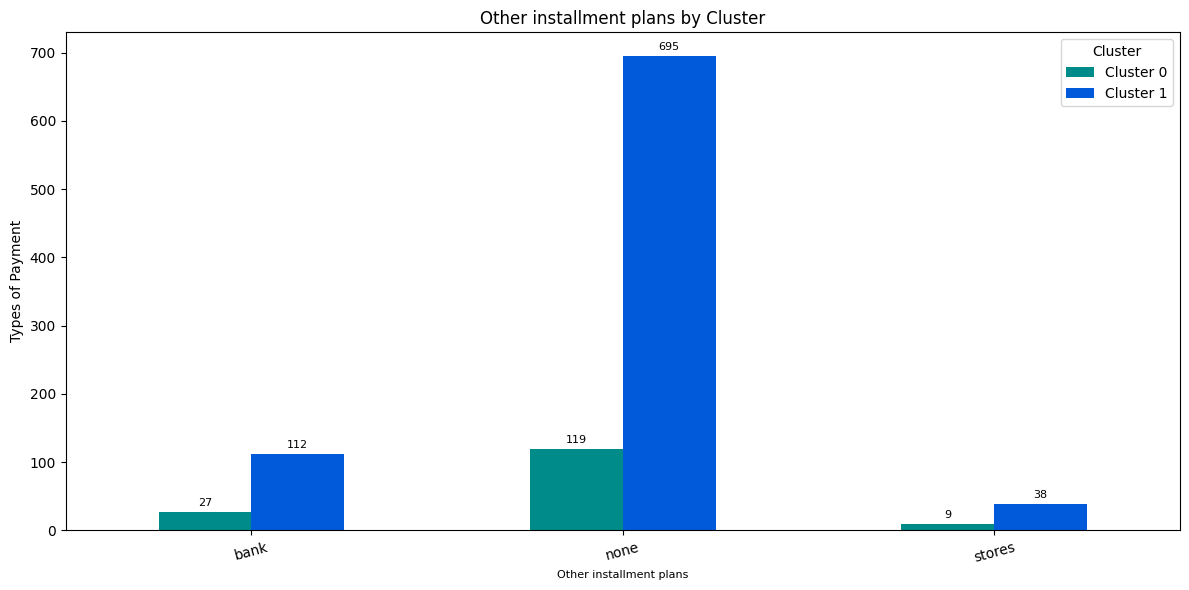

In [275]:
other_installment_plans_pivot = other_installment_plans_model_19.pivot(index = 'Other installment plans',
                                                        columns = 'Cluster',
                                                        values = 'count')

other_installment_plans_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(other_installment_plans_pivot.columns))

# plot side-by-side bars
ax = other_installment_plans_pivot.plot(kind = 'bar',
                                        figsize = (12, 6),   # width, height
                                        color = random_colors)

plt.ylabel('Types of Payment', fontsize = 10)
plt.xlabel('Other installment plans', fontsize = 8)
plt.title('Other installment plans by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)

plt.tight_layout()
plt.show()

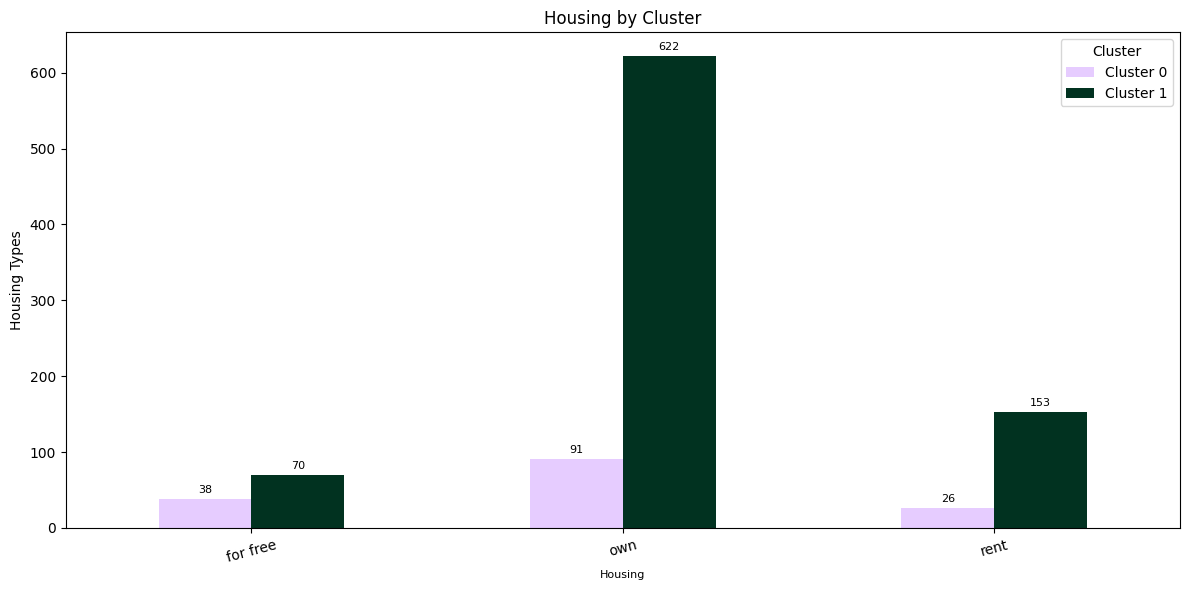

In [276]:
housing_pivot = housing_model_19.pivot(index = 'Housing',
                                       columns = 'Cluster',
                                       values = 'count')

housing_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(housing_pivot.columns))

# plot side-by-side bars
ax = housing_pivot.plot(kind = 'bar', 
                        figsize = (12, 6),   # width, height
                        color = random_colors)

plt.ylabel('Housing Types', fontsize = 10)
plt.xlabel('Housing', fontsize = 8)
plt.title('Housing by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)                   
                   
plt.tight_layout()
plt.show()

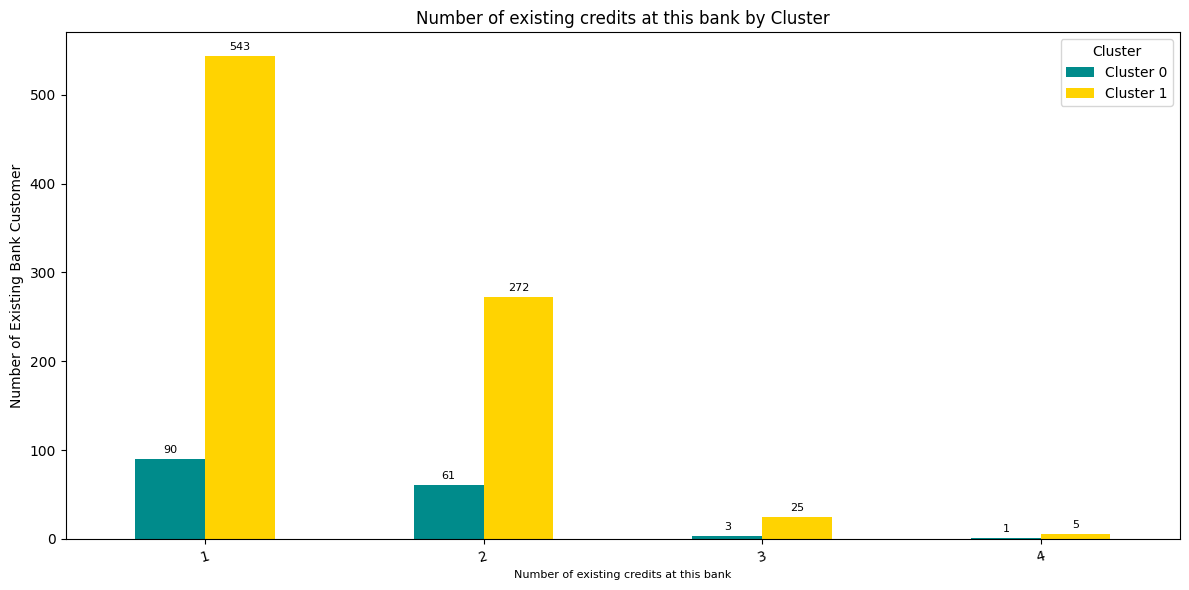

In [277]:
number_of_existing_credits_at_this_bank_pivot = number_of_existing_credits_at_this_bank_model_19.pivot(index = 'Number of existing credits at this bank',
                                                                                                       columns = 'Cluster',
                                                                                                       values = 'count')
number_of_existing_credits_at_this_bank_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(number_of_existing_credits_at_this_bank_pivot.columns))

# plot side-by-side bars
ax = number_of_existing_credits_at_this_bank_pivot.plot(kind = 'bar', 
                                                   figsize = (12, 6),   # width, height
                                                   color = random_colors)

plt.ylabel('Number of Existing Bank Customer', fontsize = 10)
plt.xlabel('Number of existing credits at this bank', fontsize = 8)
plt.title('Number of existing credits at this bank by Cluster', fontsize = 12)
plt.legend(title='Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)   
    
plt.tight_layout()
plt.show()

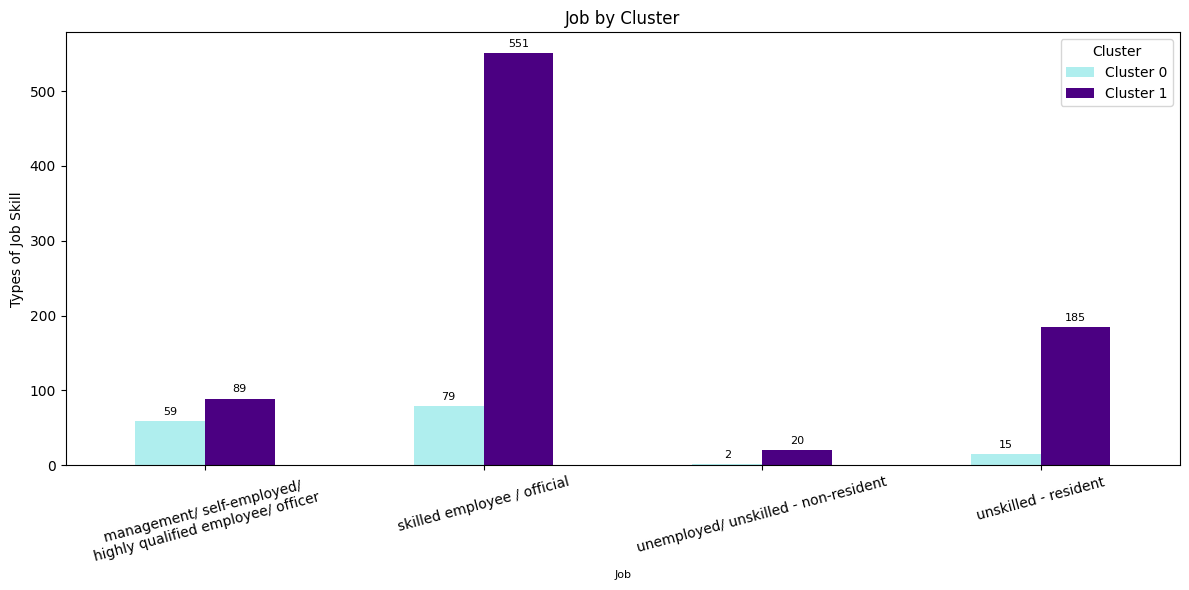

In [278]:
job_pivot = job_model_19.pivot(index = 'Job',
                               columns = 'Cluster',
                               values = 'count')

job_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(job_pivot.columns))

# plot side-by-side bars
ax = job_pivot.plot(kind = 'bar',
               figsize = (12, 6),   # width, height
               color = random_colors)

plt.ylabel('Types of Job Skill', fontsize = 10)
plt.xlabel('Job', fontsize = 8)
plt.title('Job by Cluster', fontsize = 12)
plt.legend(title='Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)   
    
plt.tight_layout()
plt.show()

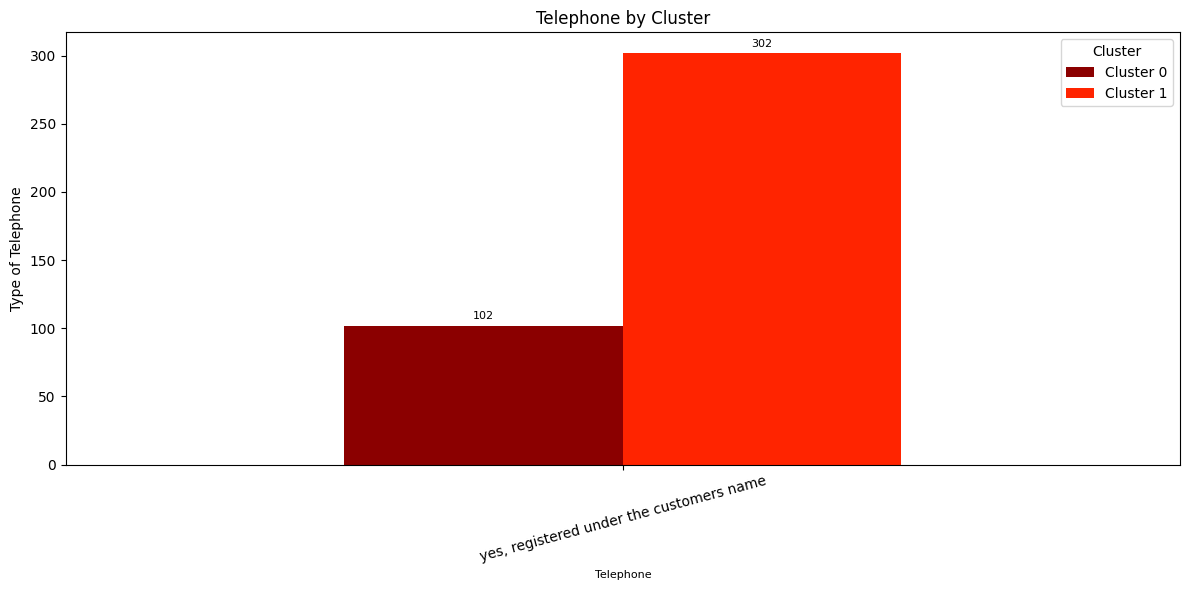

In [279]:
telephone_pivot = telephone_model_19.pivot(index = 'Telephone',
                                           columns = 'Cluster',
                                           values = 'count')

telephone_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(telephone_pivot.columns))

# plot side-by-side bars
ax = telephone_pivot.plot(kind = 'bar',
                          figsize = (12, 6),   # width, height
                          color = random_colors)

plt.ylabel('Type of Telephone', fontsize = 10)
plt.xlabel('Telephone', fontsize = 8)
plt.title('Telephone by Cluster', fontsize = 12)
plt.legend(title = 'Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)   
    
plt.tight_layout()
plt.show()

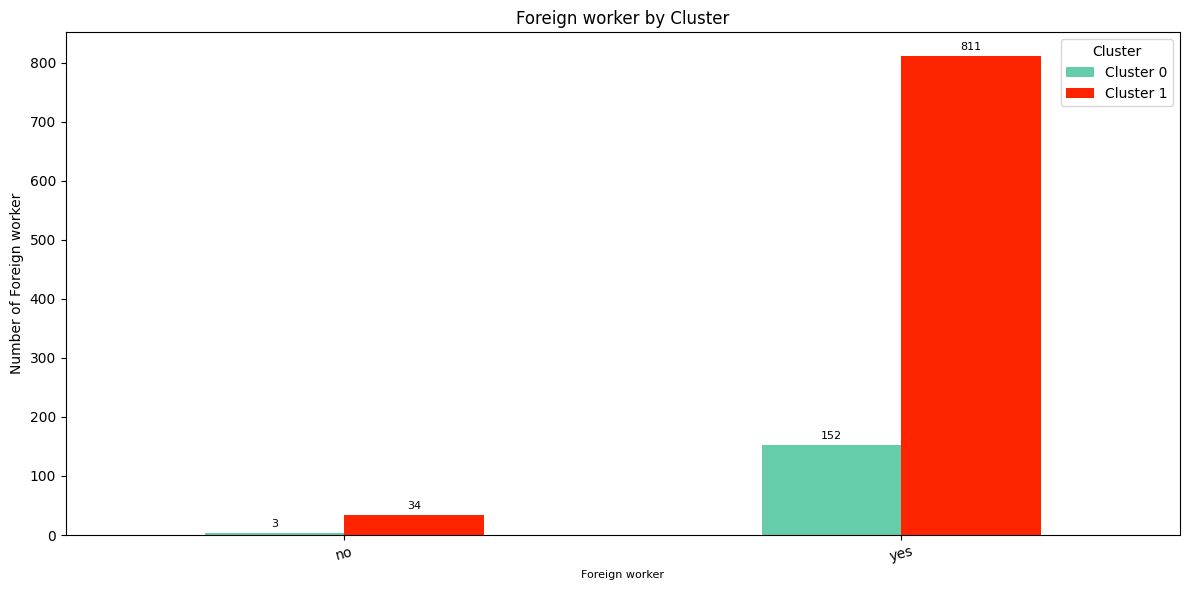

In [280]:
foreign_worker_pivot = foreign_worker_model_19.pivot(index = 'Foreign worker',
                                                     columns = 'Cluster',
                                                     values = 'count')

foreign_worker_pivot.columns = ['Cluster 0', 'Cluster 1']

# Randomly pick colors based on the number of clusters (columns)
# random.sample ensures we get unique colors from the list
random_colors = random.sample(color_pool, len(foreign_worker_pivot.columns))

# plot side-by-side bars
ax = foreign_worker_pivot.plot(kind = 'bar',
                               figsize = (12, 6),   # width, height
                               color = random_colors)
                          
plt.ylabel('Number of Foreign worker', fontsize = 10)
plt.xlabel('Foreign worker', fontsize = 8)
plt.title('Foreign worker by Cluster', fontsize = 12)
plt.legend(title='Cluster')

# plt.xticks(fontsize = 5)
# plt.yticks(fontsize = 5)

plt.xticks(rotation = 15)   # or 45

# 🔹 add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt = '%d', fontsize = 8, padding = 3)   
    
plt.tight_layout()
plt.show()

### Step 4.0 Summarise and Interpret
- Summarise your finding in a table and provide names for clusters.
- Provide an interpretation of each cluster.
  

Yes, as Cluster 0 seems to be very low number compared to Cluster 1.   
Each cluster 0 have low rate due to the model 19 percentage.   



Cluster 1: 98.7  
CLuster 0: 15.5  

Need improvement:
Yes!

Feature for Telephone:
Telephone feature have a null value of 596. 

### The End